In [12]:
# Create mapping - keep prefixes, update suffixes only
name_mapping = {
    # Myeloid - keep "Myeloid_" prefix
    'Myeloid_DC2': 'Myeloid_cDC2',
    'Myeloid_Macrophage': 'Myeloid_Mac-A',
    'Myeloid_Macrophage-CXCL9/10': 'Myeloid_Mac-B',
    'Myeloid_cDC1': 'Myeloid_cDC1',
    'Myeloid_marginalzone': 'Myeloid_Mac-F4/80',
    'Myeloid_migratory': 'Myeloid_MigDC',
    'Myeloid_moDC': 'Myeloid_moDC-A',
    'Myeloid_moDC-CXCL9/10': 'Myeloid_moDC-B',
    'Myeloid_monocyte': 'Myeloid_Monocyte',
    'Myeloid_pDC': 'Myeloid_pDC',
    # CD8 - keep as is (already match paper names)
    'CD8-Tcell_naive': 'CD8-Tcell_naive',
    'CD8-Tcell_early-active': 'CD8-Tcell_early-active',
    'CD8-Tcell_effector': 'CD8-Tcell_effector',
    'CD8-Tcell_late-active': 'CD8-Tcell_late-active',
    'CD8-Tcell_terminal': 'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating': 'CD8-Tcell_proliferating'
}

# Recreate heatmap with corrected names
print("Creating CD8 - Myeloid Heatmap with Paper Names\n")

conventional_cd8 = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active', 
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
    'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating'
]

myeloid_types = [ct for ct in diff_results['cell_type_1'].unique() if 'Myeloid' in ct]

cd8_myeloid_raw = moran_results[
    ((moran_results['cell_type_1'].isin(conventional_cd8) & moran_results['cell_type_2'].isin(myeloid_types)) |
     (moran_results['cell_type_2'].isin(conventional_cd8) & moran_results['cell_type_1'].isin(myeloid_types)))
].copy()

# Standardize so CD8 is always in cell_type_1
for idx, row in cd8_myeloid_raw.iterrows():
    if row['cell_type_1'] in myeloid_types:
        cd8_myeloid_raw.at[idx, 'cell_type_1'] = row['cell_type_2']
        cd8_myeloid_raw.at[idx, 'cell_type_2'] = row['cell_type_1']

# Calculate means per condition
mean_values = cd8_myeloid_raw.groupby(['cell_type_1', 'cell_type_2', 'condition'])['I'].mean().reset_index()

# Create matrices
infected_matrix = mean_values[mean_values['condition'] == 'infected'].pivot(
    index='cell_type_1', columns='cell_type_2', values='I'
)
uninfected_matrix = mean_values[mean_values['condition'] == 'uninfected'].pivot(
    index='cell_type_1', columns='cell_type_2', values='I'
)

# Calculate difference
diff_matrix = infected_matrix - uninfected_matrix

# Reorder
row_order = conventional_cd8
diff_matrix = diff_matrix.reindex(row_order)

# Rename rows and columns to paper names
diff_matrix.index = [name_mapping.get(idx, idx) for idx in diff_matrix.index]
diff_matrix.columns = [name_mapping.get(col, col) for col in diff_matrix.columns]

# Cluster columns
from scipy.cluster.hierarchy import dendrogram, linkage
valid_cols = diff_matrix.columns[~diff_matrix.isna().all()]
linkage_matrix = linkage(diff_matrix[valid_cols].T.fillna(0), method='average', metric='euclidean')
col_order = valid_cols[dendrogram(linkage_matrix, no_plot=True)['leaves']]
diff_matrix = diff_matrix[col_order]

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    diff_matrix,
    cmap='RdBu_r',
    center=0,
    vmin=-0.4,
    vmax=0.4,
    cbar_kws={'label': 'Δ Bivariate Moran\'s I\n(Infected - Uninfected)', 'shrink': 0.8},
    linewidths=0.5,
    linecolor='white',
    square=False,
    ax=ax,
    annot=False,
    fmt='.2f',
    annot_kws={'size': 8, 'weight': 'bold'}
)

ax.set_xlabel('Myeloid Cell Type', fontsize=13, fontweight='bold')
ax.set_ylabel('CD8 T Cell Type', fontsize=13, fontweight='bold')
ax.set_title('Differential Spatial Colocalization: CD8 T cells - Myeloid Cells\nInfected vs Uninfected', 
             fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('cd8_myeloid_colocalization_heatmap_paper_names.png', dpi=300, bbox_inches='tight')
plt.savefig('cd8_myeloid_colocalization_heatmap_paper_names.pdf', bbox_inches='tight')
print("📊 Saved: cd8_myeloid_colocalization_heatmap_paper_names.png/pdf")
plt.show()

print("\nHeatmap shows Δ Bivariate Moran's I (Infected - Uninfected)")
print("Red = stronger colocalization in infected | Blue = stronger in uninfected")

Creating CD8 - Myeloid Heatmap with Paper Names



NameError: name 'diff_results' is not defined

RECALCULATING SPATIAL NEIGHBORS WITH PROPER DISTANCE THRESHOLD
Using distance-based neighbors instead of k-nearest neighbors

Creating distance-based spatial neighbors...
Using radius = 300 coordinate units (approximately immediate neighbors)

V1S1:
  Total spots: 648
  Spots with neighbors: 648
  Isolated spots: 0 (0.0%)
  Mean neighbors: 5.7

V1S2:
  Total spots: 620
  Spots with neighbors: 620
  Isolated spots: 0 (0.0%)
  Mean neighbors: 5.7

CALCULATING GLOBAL BIVARIATE MORAN'S I
Using corrected distance-based spatial weights

V1S1:
  [1/60] CD8-Tcell_naive - Myeloid_DC2... done
  [2/60] CD8-Tcell_naive - Myeloid_Macrophage... done
  [3/60] CD8-Tcell_naive - Myeloid_Macrophage-CXCL9/10... done
  [4/60] CD8-Tcell_naive - Myeloid_cDC1... done
  [5/60] CD8-Tcell_naive - Myeloid_marginalzone... done
  [6/60] CD8-Tcell_naive - Myeloid_migratory... done
  [7/60] CD8-Tcell_naive - Myeloid_moDC... done
  [8/60] CD8-Tcell_naive - Myeloid_moDC-CXCL9/10... done
  [9/60] CD8-Tcell_naive - Myel

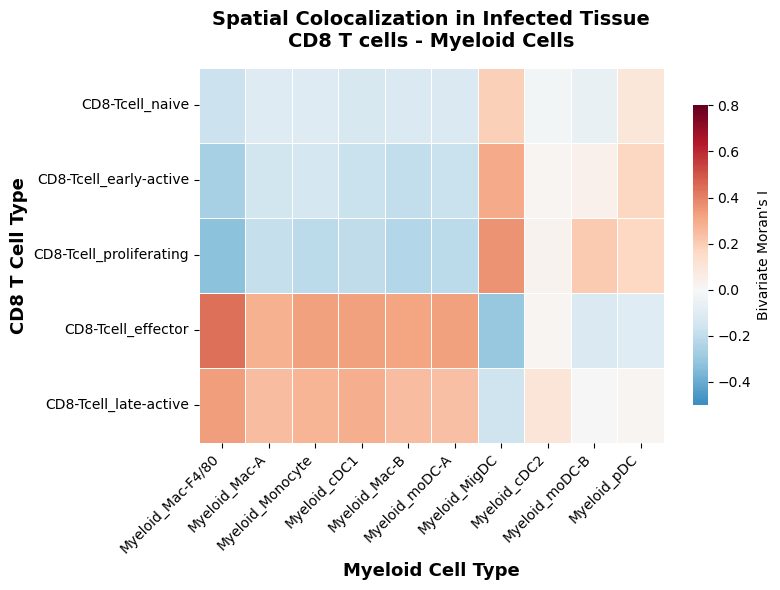

💾 Saved: global_morans_i_corrected.csv

COMPLETE - GLOBAL ANALYSIS WITH CORRECTED SPATIAL NEIGHBORS


In [ ]:
from esda.moran import Moran_BV
from libpysal.weights import W
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

print("="*80)
print("RECALCULATING SPATIAL NEIGHBORS WITH PROPER DISTANCE THRESHOLD")
print("="*80)
print("Using distance-based neighbors instead of k-nearest neighbors")
print("="*80 + "\n")

# Load data
infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
adata_infected = sc.read_h5ad(infected_path)

# Define cell types
conventional_cd8 = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active', 
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
    'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating'
]

myeloid_types = [ct for ct in adata_infected.obsm['means_cell_abundance_w_sf'].columns 
                 if 'Myeloid' in ct]

# YOUR EXACT NAME MAPPING
name_mapping = {
    'Myeloid_DC2': 'Myeloid_cDC2',
    'Myeloid_Macrophage': 'Myeloid_Mac-A',
    'Myeloid_Macrophage-CXCL9/10': 'Myeloid_Mac-B',
    'Myeloid_cDC1': 'Myeloid_cDC1',
    'Myeloid_marginalzone': 'Myeloid_Mac-F4/80',
    'Myeloid_migratory': 'Myeloid_MigDC',
    'Myeloid_moDC': 'Myeloid_moDC-A',
    'Myeloid_moDC-CXCL9/10': 'Myeloid_moDC-B',
    'Myeloid_monocyte': 'Myeloid_Monocyte',
    'Myeloid_pDC': 'Myeloid_pDC',
}

# ============================================================================
# CREATE DISTANCE-BASED SPATIAL NEIGHBORS
# ============================================================================

def create_distance_based_weights(coords, radius=300):
    """
    Create spatial weights based on distance threshold
    radius: maximum distance for neighbors (in coordinate units)
    """
    n_spots = coords.shape[0]
    
    # Use ball tree for efficient radius search
    nbrs = NearestNeighbors(radius=radius, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.radius_neighbors(coords)
    
    # Build W object
    neighbors = {}
    weights_dict = {}
    
    for i in range(n_spots):
        neighbor_idx = indices[i]
        neighbor_dist = distances[i]
        
        # Remove self
        mask = neighbor_idx != i
        neighbor_idx = neighbor_idx[mask]
        neighbor_dist = neighbor_dist[mask]
        
        if len(neighbor_idx) > 0:
            # Weight by inverse distance
            weights = 1.0 / (neighbor_dist + 1e-10)
            
            neighbors[i] = neighbor_idx.tolist()
            weights_dict[i] = weights.tolist()
    
    w = W(neighbors, weights_dict)
    return w

print("Creating distance-based spatial neighbors...")
print("Using radius = 300 coordinate units (approximately immediate neighbors)")
print()

weights_dict = {}
indices_dict = {}

for sample in ['V1S1', 'V1S2']:
    mask = (adata_infected.obs['sample'] == sample).values
    indices = np.where(mask)[0]
    coords = adata_infected.obsm['spatial'][mask]
    
    w = create_distance_based_weights(coords, radius=300)
    weights_dict[sample] = w
    indices_dict[sample] = indices
    
    # Check isolation
    n_isolated = sum(1 for i in range(len(indices)) if i not in w.neighbors)
    pct_isolated = (n_isolated / len(indices)) * 100
    
    print(f"{sample}:")
    print(f"  Total spots: {len(indices)}")
    print(f"  Spots with neighbors: {w.n}")
    print(f"  Isolated spots: {n_isolated} ({pct_isolated:.1f}%)")
    print(f"  Mean neighbors: {w.mean_neighbors:.1f}")
    print()

# ============================================================================
# CALCULATE GLOBAL BIVARIATE MORAN'S I
# ============================================================================

print("="*80)
print("CALCULATING GLOBAL BIVARIATE MORAN'S I")
print("="*80)
print("Using corrected distance-based spatial weights")
print("="*80 + "\n")

all_results = []

for sample in ['V1S1', 'V1S2']:
    print(f"{sample}:")
    
    indices = indices_dict[sample]
    abundances = adata_infected.obsm['means_cell_abundance_w_sf'].iloc[indices]
    w = weights_dict[sample]
    
    # Only use spots that have neighbors
    connected_spots = list(w.neighbors.keys())
    abundances_connected = abundances.iloc[connected_spots]
    
    pair_count = 0
    total_pairs = len(conventional_cd8) * len(myeloid_types)
    
    for cd8 in conventional_cd8:
        for myeloid in myeloid_types:
            pair_count += 1
            print(f"  [{pair_count}/{total_pairs}] {cd8} - {myeloid}...", end="")
            
            try:
                x = abundances_connected[cd8].values.astype(np.float64)
                y = abundances_connected[myeloid].values.astype(np.float64)
                
                if x.std() == 0 or y.std() == 0:
                    print(" skipped (no variance)")
                    continue
                
                # Global Bivariate Moran's I
                moran_bv = Moran_BV(x, y, w, permutations=9999)
                
                all_results.append({
                    'sample': sample,
                    'condition': 'infected',
                    'cell_type_1': cd8,
                    'cell_type_2': myeloid,
                    'I': moran_bv.I,
                    'p_value': moran_bv.p_sim,
                    'n_spots': len(connected_spots)
                })
                
                print(" done")
                
            except Exception as e:
                print(f" failed: {e}")
                continue
    
    print()

moran_results = pd.DataFrame(all_results)
print(f"✅ Complete! {len(moran_results)} calculations")

# ============================================================================
# CREATE HEATMAP - INFECTED ONLY
# ============================================================================

print("\n" + "="*80)
print("CREATING HEATMAP")
print("="*80)

# Filter for CD8-Myeloid pairs
cd8_myeloid_raw = moran_results[
    ((moran_results['cell_type_1'].isin(conventional_cd8) & moran_results['cell_type_2'].isin(myeloid_types)) |
     (moran_results['cell_type_2'].isin(conventional_cd8) & moran_results['cell_type_1'].isin(myeloid_types)))
].copy()

# Standardize so CD8 is always in cell_type_1
for idx, row in cd8_myeloid_raw.iterrows():
    if row['cell_type_1'] in myeloid_types:
        cd8_myeloid_raw.at[idx, 'cell_type_1'] = row['cell_type_2']
        cd8_myeloid_raw.at[idx, 'cell_type_2'] = row['cell_type_1']

# Calculate mean across infected samples
mean_values = cd8_myeloid_raw.groupby(['cell_type_1', 'cell_type_2'])['I'].mean().reset_index()

# Create matrix
# Create matrix
infected_matrix = mean_values.pivot(
    index='cell_type_1', 
    columns='cell_type_2', 
    values='I'
)

# Reorder rows - custom order: naive, early-active, proliferating, effector, late-active, terminal
cd8_row_order = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active',
    'CD8-Tcell_proliferating',
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
]
infected_matrix = infected_matrix.reindex(cd8_row_order)

# Rename to paper names (only applies to columns since rows are CD8)
infected_matrix.columns = [name_mapping.get(col, col) for col in infected_matrix.columns]

# Cluster columns
from scipy.cluster.hierarchy import dendrogram, linkage
valid_cols = infected_matrix.columns[~infected_matrix.isna().all()]
linkage_matrix = linkage(infected_matrix[valid_cols].T.fillna(0), method='average', metric='euclidean')
col_order = valid_cols[dendrogram(linkage_matrix, no_plot=True)['leaves']]
infected_matrix = infected_matrix[col_order]

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    infected_matrix,
    cmap='RdBu_r',
    center=0,
    vmin=-0.5,
    vmax=0.8,
    cbar_kws={'label': 'Bivariate Moran\'s I', 'shrink': 0.8},
    linewidths=0.5,
    linecolor='white',
    square=False,
    ax=ax,
    annot=False,
    fmt='.2f'
)

ax.set_xlabel('Myeloid Cell Type', fontsize=13, fontweight='bold')
ax.set_ylabel('CD8 T Cell Type', fontsize=13, fontweight='bold')
ax.set_title('Spatial Colocalization in Infected Tissue\nCD8 T cells - Myeloid Cells', 
             fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('cd8_myeloid_colocalization_infected_CORRECTED.png', dpi=300, bbox_inches='tight')
plt.savefig('cd8_myeloid_colocalization_infected_CORRECTED.pdf', bbox_inches='tight')
print("\n📊 Saved: cd8_myeloid_colocalization_infected_CORRECTED.png/pdf")
plt.show()

# Save results
moran_results.to_csv('global_morans_i_corrected.csv', index=False)
print("💾 Saved: global_morans_i_corrected.csv")

print("\n" + "="*80)
print("COMPLETE - GLOBAL ANALYSIS WITH CORRECTED SPATIAL NEIGHBORS")
print("="*80)

In [ ]:
# Check p-values
print("P-values for CD8-Myeloid colocalization:")
print(moran_results[['sample', 'cell_type_1', 'cell_type_2', 'I', 'p_value']].to_string())

print("\n\nSummary:")
print(f"Significant at p < 0.05: {(moran_results['p_value'] < 0.05).sum()}/{len(moran_results)}")
print(f"Significant at p < 0.01: {(moran_results['p_value'] < 0.01).sum()}/{len(moran_results)}")


P-values for CD8-Myeloid colocalization:
    sample              cell_type_1                  cell_type_2         I  p_value
0     V1S1          CD8-Tcell_naive                  Myeloid_DC2 -0.045111   0.0273
1     V1S1          CD8-Tcell_naive           Myeloid_Macrophage -0.131616   0.0001
2     V1S1          CD8-Tcell_naive  Myeloid_Macrophage-CXCL9/10 -0.170320   0.0001
3     V1S1          CD8-Tcell_naive                 Myeloid_cDC1 -0.178292   0.0001
4     V1S1          CD8-Tcell_naive         Myeloid_marginalzone -0.229162   0.0001
5     V1S1          CD8-Tcell_naive            Myeloid_migratory  0.248756   0.0001
6     V1S1          CD8-Tcell_naive                 Myeloid_moDC -0.173312   0.0001
7     V1S1          CD8-Tcell_naive        Myeloid_moDC-CXCL9/10 -0.048694   0.0209
8     V1S1          CD8-Tcell_naive             Myeloid_monocyte -0.160722   0.0001
9     V1S1          CD8-Tcell_naive                  Myeloid_pDC  0.108233   0.0005
10    V1S1   CD8-Tcell_early-active

In [ ]:
# Apply FDR correction
from statsmodels.stats.multitest import multipletests

# Correct p-values across all tests
_, moran_results['p_value_fdr'], _, _ = multipletests(
    moran_results['p_value'], 
    method='fdr_bh'
)

# Summary with FDR
print("After FDR correction:")
print(f"Significant at FDR < 0.05: {(moran_results['p_value_fdr'] < 0.05).sum()}/{len(moran_results)}")
print(f"Significant at FDR < 0.01: {(moran_results['p_value_fdr'] < 0.01).sum()}/{len(moran_results)}")

# Show which pairs are still significant
print("\nAll results with FDR:")
print(moran_results[['sample', 'cell_type_1', 'cell_type_2', 'I', 'p_value', 'p_value_fdr']].to_string())

After FDR correction:
Significant at FDR < 0.05: 110/120
Significant at FDR < 0.01: 100/120

All results with FDR:
    sample              cell_type_1                  cell_type_2         I  p_value  p_value_fdr
0     V1S1          CD8-Tcell_naive                  Myeloid_DC2 -0.045111   0.0273     0.031500
1     V1S1          CD8-Tcell_naive           Myeloid_Macrophage -0.131616   0.0001     0.000136
2     V1S1          CD8-Tcell_naive  Myeloid_Macrophage-CXCL9/10 -0.170320   0.0001     0.000136
3     V1S1          CD8-Tcell_naive                 Myeloid_cDC1 -0.178292   0.0001     0.000136
4     V1S1          CD8-Tcell_naive         Myeloid_marginalzone -0.229162   0.0001     0.000136
5     V1S1          CD8-Tcell_naive            Myeloid_migratory  0.248756   0.0001     0.000136
6     V1S1          CD8-Tcell_naive                 Myeloid_moDC -0.173312   0.0001     0.000136
7     V1S1          CD8-Tcell_naive        Myeloid_moDC-CXCL9/10 -0.048694   0.0209     0.024466
8     V1S1  

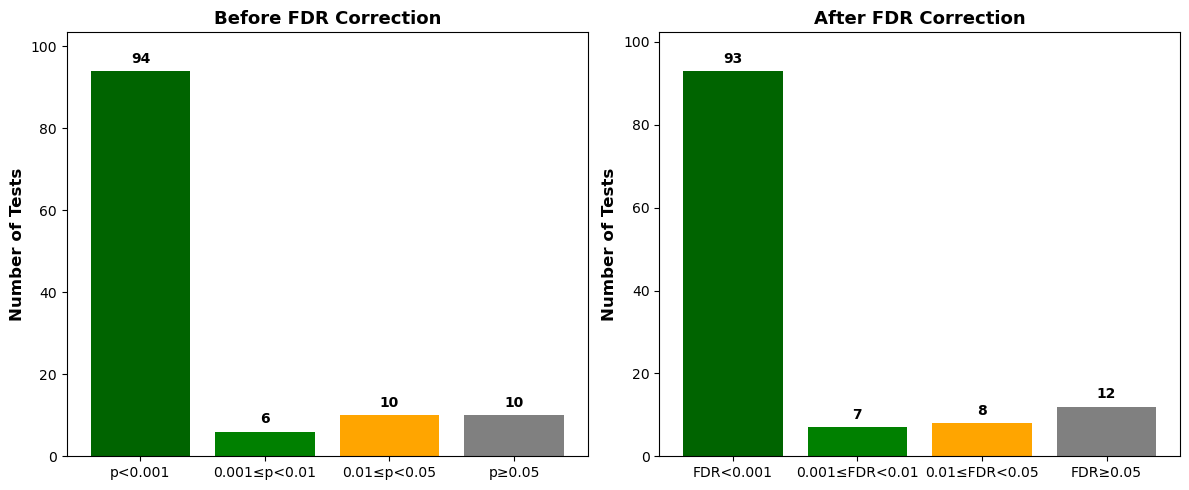


📊 Significant at p<0.05: 110/120
📊 Significant at FDR<0.05: 108/120


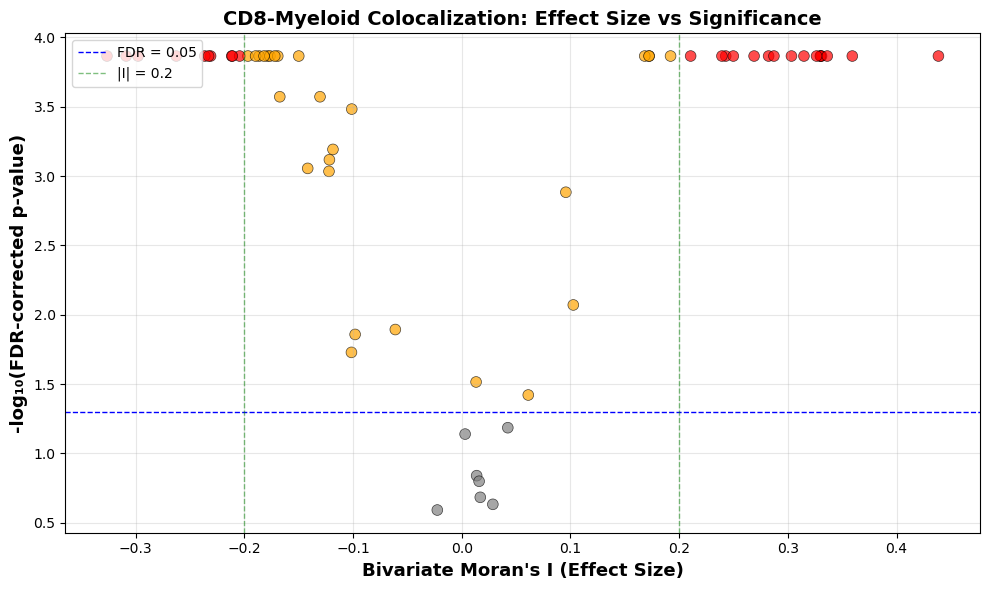


📊 Significant (FDR<0.05) with large effect (|I|>0.2): 26


/var/folders/qb/hfnm72x95497q4_ptv95pn8r0000gn/T/ipykernel_3497/1423629678.py:145: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_matrix = fdr_matrix.applymap(


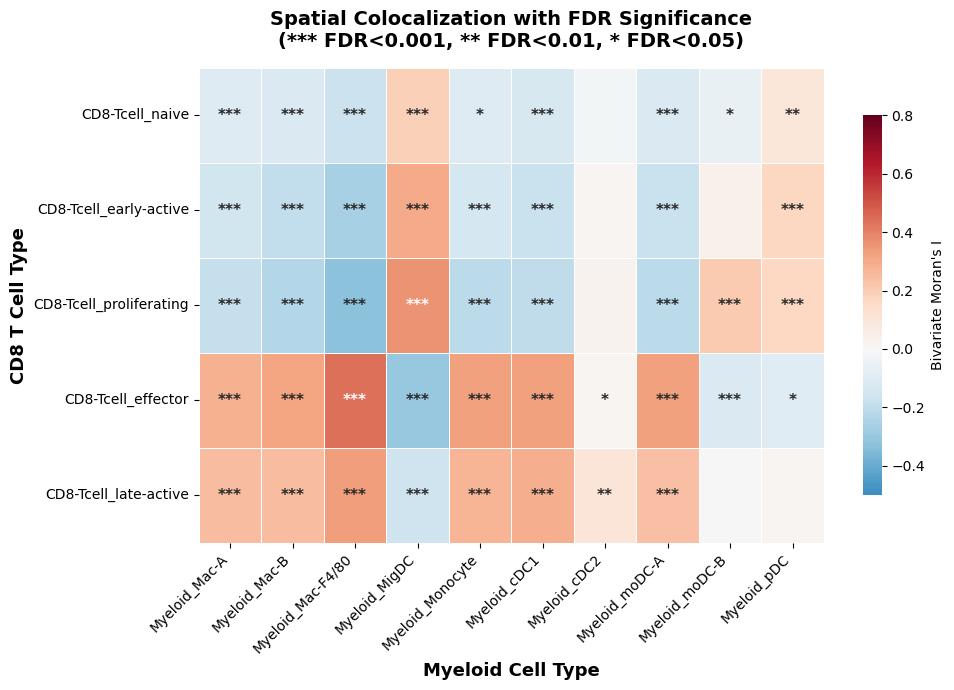


✅ Visualizations complete!


In [ ]:
# ============================================================================
# VISUALIZE P-VALUES AND FDR CORRECTION
# ============================================================================

from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply FDR correction
_, moran_results['p_value_fdr'], _, _ = multipletests(
    moran_results['p_value'], 
    method='fdr_bh'
)

# Filter for CD8-Myeloid pairs
cd8_myeloid = moran_results[
    ((moran_results['cell_type_1'].isin(conventional_cd8) & 
      moran_results['cell_type_2'].isin(myeloid_types)) |
     (moran_results['cell_type_2'].isin(conventional_cd8) & 
      moran_results['cell_type_1'].isin(myeloid_types)))
].copy()

# Standardize so CD8 is always in cell_type_1
for idx, row in cd8_myeloid.iterrows():
    if row['cell_type_1'] in myeloid_types:
        cd8_myeloid.at[idx, 'cell_type_1'] = row['cell_type_2']
        cd8_myeloid.at[idx, 'cell_type_2'] = row['cell_type_1']

# Rename myeloid types
cd8_myeloid['cell_type_2'] = cd8_myeloid['cell_type_2'].map(name_mapping)

# Calculate mean values across samples
mean_stats = cd8_myeloid.groupby(['cell_type_1', 'cell_type_2']).agg({
    'I': 'mean',
    'p_value': 'mean',
    'p_value_fdr': 'mean'
}).reset_index()

# ============================================================================
# PLOT 1: Summary bar chart
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before FDR
sig_counts_raw = [
    (cd8_myeloid['p_value'] < 0.001).sum(),
    ((cd8_myeloid['p_value'] >= 0.001) & (cd8_myeloid['p_value'] < 0.01)).sum(),
    ((cd8_myeloid['p_value'] >= 0.01) & (cd8_myeloid['p_value'] < 0.05)).sum(),
    (cd8_myeloid['p_value'] >= 0.05).sum()
]

axes[0].bar(['p<0.001', '0.001≤p<0.01', '0.01≤p<0.05', 'p≥0.05'], 
            sig_counts_raw, color=['darkgreen', 'green', 'orange', 'gray'])
axes[0].set_ylabel('Number of Tests', fontsize=12, fontweight='bold')
axes[0].set_title('Before FDR Correction', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(sig_counts_raw) * 1.1)
for i, v in enumerate(sig_counts_raw):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# After FDR
sig_counts_fdr = [
    (cd8_myeloid['p_value_fdr'] < 0.001).sum(),
    ((cd8_myeloid['p_value_fdr'] >= 0.001) & (cd8_myeloid['p_value_fdr'] < 0.01)).sum(),
    ((cd8_myeloid['p_value_fdr'] >= 0.01) & (cd8_myeloid['p_value_fdr'] < 0.05)).sum(),
    (cd8_myeloid['p_value_fdr'] >= 0.05).sum()
]

axes[1].bar(['FDR<0.001', '0.001≤FDR<0.01', '0.01≤FDR<0.05', 'FDR≥0.05'], 
            sig_counts_fdr, color=['darkgreen', 'green', 'orange', 'gray'])
axes[1].set_ylabel('Number of Tests', fontsize=12, fontweight='bold')
axes[1].set_title('After FDR Correction', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(sig_counts_fdr) * 1.1)
for i, v in enumerate(sig_counts_fdr):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('significance_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Significant at p<0.05: {(cd8_myeloid['p_value'] < 0.05).sum()}/{len(cd8_myeloid)}")
print(f"📊 Significant at FDR<0.05: {(cd8_myeloid['p_value_fdr'] < 0.05).sum()}/{len(cd8_myeloid)}")

# ============================================================================
# PLOT 2: Effect size vs significance (volcano-style)
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Add -log10(p) for visualization
mean_stats['neg_log10_p'] = -np.log10(mean_stats['p_value_fdr'])

# Color by significance and effect size
colors = []
for _, row in mean_stats.iterrows():
    if row['p_value_fdr'] < 0.05 and abs(row['I']) > 0.2:
        colors.append('red')  # Significant AND large effect
    elif row['p_value_fdr'] < 0.05:
        colors.append('orange')  # Significant but small effect
    else:
        colors.append('gray')  # Not significant

ax.scatter(mean_stats['I'], mean_stats['neg_log10_p'], 
           c=colors, s=60, alpha=0.7, edgecolors='black', linewidths=0.5)

# Add threshold lines
ax.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=1, label='FDR = 0.05')
ax.axvline(0.2, color='green', linestyle='--', linewidth=1, alpha=0.5, label='|I| = 0.2')
ax.axvline(-0.2, color='green', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Bivariate Moran\'s I (Effect Size)', fontsize=13, fontweight='bold')
ax.set_ylabel('-log₁₀(FDR-corrected p-value)', fontsize=13, fontweight='bold')
ax.set_title('CD8-Myeloid Colocalization: Effect Size vs Significance', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('effect_size_vs_significance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Significant (FDR<0.05) with large effect (|I|>0.2): {((mean_stats['p_value_fdr'] < 0.05) & (abs(mean_stats['I']) > 0.2)).sum()}")

# ============================================================================
# PLOT 3: Heatmap with significance stars
# ============================================================================

# Create matrices
I_matrix = mean_stats.pivot(index='cell_type_1', columns='cell_type_2', values='I')
fdr_matrix = mean_stats.pivot(index='cell_type_1', columns='cell_type_2', values='p_value_fdr')

# Reorder rows
cd8_row_order = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active',
    'CD8-Tcell_proliferating',
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
]
I_matrix = I_matrix.reindex(cd8_row_order)
fdr_matrix = fdr_matrix.reindex(cd8_row_order)

# Create annotation matrix with stars
annot_matrix = fdr_matrix.applymap(
    lambda x: '***' if x < 0.001 else ('**' if x < 0.01 else ('*' if x < 0.05 else ''))
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    I_matrix,
    cmap='RdBu_r',
    center=0,
    vmin=-0.5,
    vmax=0.8,
    cbar_kws={'label': 'Bivariate Moran\'s I', 'shrink': 0.8},
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot=annot_matrix,
    fmt='',
    annot_kws={'fontsize': 11, 'fontweight': 'bold'}
)

ax.set_xlabel('Myeloid Cell Type', fontsize=13, fontweight='bold')
ax.set_ylabel('CD8 T Cell Type', fontsize=13, fontweight='bold')
ax.set_title('Spatial Colocalization with FDR Significance\n(*** FDR<0.001, ** FDR<0.01, * FDR<0.05)', 
             fontsize=14, fontweight='bold', pad=15)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('colocalization_heatmap_with_FDR_stars.png', dpi=300, bbox_inches='tight')
plt.savefig('colocalization_heatmap_with_FDR_stars.pdf', bbox_inches='tight')
plt.show()

print("\n✅ Visualizations complete!")

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np

# Load data
infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'

adata_infected = sc.read_h5ad(infected_path)

# Cell type definitions
conventional_cd8 = [
    'CD8-Tcell_naive', 'CD8-Tcell_early-active', 'CD8-Tcell_effector',
    'CD8-Tcell_late-active', 'CD8-Tcell_terminal', 'CD8-Tcell_proliferating'
]

myeloid_types = [ct for ct in adata_infected.obsm['means_cell_abundance_w_sf'].columns 
                 if 'Myeloid' in ct]

print("="*80)
print("ACTUAL CD8 ABUNDANCES BY CLUSTER")
print("="*80)

for sample in ['V1S1', 'V1S2']:
    print(f"\n{sample}:")
    print("-"*80)
    
    sample_data = adata_infected[adata_infected.obs['sample'] == sample]
    clusters = sorted(sample_data.obs['paper_clusters'].unique())
    
    for cluster in clusters:
        cluster_mask = sample_data.obs['paper_clusters'] == cluster
        cluster_spots = sample_data[cluster_mask]
        abundances = cluster_spots.obsm['means_cell_abundance_w_sf']
        
        print(f"\n{cluster} (n={cluster_spots.n_obs} spots):")
        
        for cd8 in conventional_cd8:
            if cd8 in abundances.columns:
                mean_val = abundances[cd8].mean()
                max_val = abundances[cd8].max()
                cd8_short = cd8.replace('CD8-Tcell_', '')
                print(f"  {cd8_short:20s}: mean={mean_val:.4f}, max={max_val:.4f}")

print("\n" + "="*80)
print("CHECK: Are effectors present in White Pulp clusters?")
print("="*80)

wp_clusters = ['WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
rp_clusters = ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag']

effector_in_wp = []
effector_in_rp = []

for sample in ['V1S1', 'V1S2']:
    sample_data = adata_infected[adata_infected.obs['sample'] == sample]
    
    for cluster in wp_clusters:
        if cluster in sample_data.obs['paper_clusters'].values:
            cluster_spots = sample_data[sample_data.obs['paper_clusters'] == cluster]
            abundances = cluster_spots.obsm['means_cell_abundance_w_sf']
            if 'CD8-Tcell_effector' in abundances.columns:
                mean_eff = abundances['CD8-Tcell_effector'].mean()
                effector_in_wp.append(mean_eff)
    
    for cluster in rp_clusters:
        if cluster in sample_data.obs['paper_clusters'].values:
            cluster_spots = sample_data[sample_data.obs['paper_clusters'] == cluster]
            abundances = cluster_spots.obsm['means_cell_abundance_w_sf']
            if 'CD8-Tcell_effector' in abundances.columns:
                mean_eff = abundances['CD8-Tcell_effector'].mean()
                effector_in_rp.append(mean_eff)

print(f"\nCD8_Effector in White Pulp: mean={np.mean(effector_in_wp):.4f}, range=[{np.min(effector_in_wp):.4f}, {np.max(effector_in_wp):.4f}]")
print(f"CD8_Effector in Red Pulp:   mean={np.mean(effector_in_rp):.4f}, range=[{np.min(effector_in_rp):.4f}, {np.max(effector_in_rp):.4f}]")

ACTUAL CD8 ABUNDANCES BY CLUSTER

V1S1:
--------------------------------------------------------------------------------

RP-A: GZMK (n=97 spots):
  naive               : mean=0.3141, max=0.5886
  early-active        : mean=0.2914, max=0.5060
  effector            : mean=0.4011, max=1.2014
  late-active         : mean=0.2864, max=0.6036
  terminal            : mean=0.2656, max=0.4580
  proliferating       : mean=0.3975, max=1.1752

RP-B: H_MK (n=32 spots):
  naive               : mean=0.2330, max=0.4812
  early-active        : mean=0.2196, max=0.4763
  effector            : mean=0.2997, max=0.6348
  late-active         : mean=0.2279, max=0.3888
  terminal            : mean=0.2118, max=0.3791
  proliferating       : mean=0.2757, max=0.5737

RP-C: NGP (n=46 spots):
  naive               : mean=0.2591, max=0.5179
  early-active        : mean=0.2351, max=0.4722
  effector            : mean=0.2768, max=0.6574
  late-active         : mean=0.2204, max=0.5308
  terminal            : mean=0.217

DIRECT COMPARISON: Which pairs colocalize and where?

STEP 1: Pairs with Significant Spatial Colocalization (Moran's I)
--------------------------------------------------------------------------------

16 pairs with significant positive colocalization (I>0.2, p<0.05):

        cd8_short        myeloid_short         I  p_value
14       effector         marginalzone  0.438454    0.001
45  proliferating            migratory  0.359228    0.001
24    late-active         marginalzone  0.336194    0.001
13       effector                 cDC1  0.330918    0.001
16       effector                 moDC  0.330016    0.001
18       effector             monocyte  0.329933    0.001
55       terminal            migratory  0.326354    0.001
12       effector  Macrophage-CXCL9/10  0.314740    0.001
5    early-active            migratory  0.303247    0.001
23    late-active                 cDC1  0.287130    0.001
11       effector           Macrophage  0.282241    0.001
28    late-active             mono

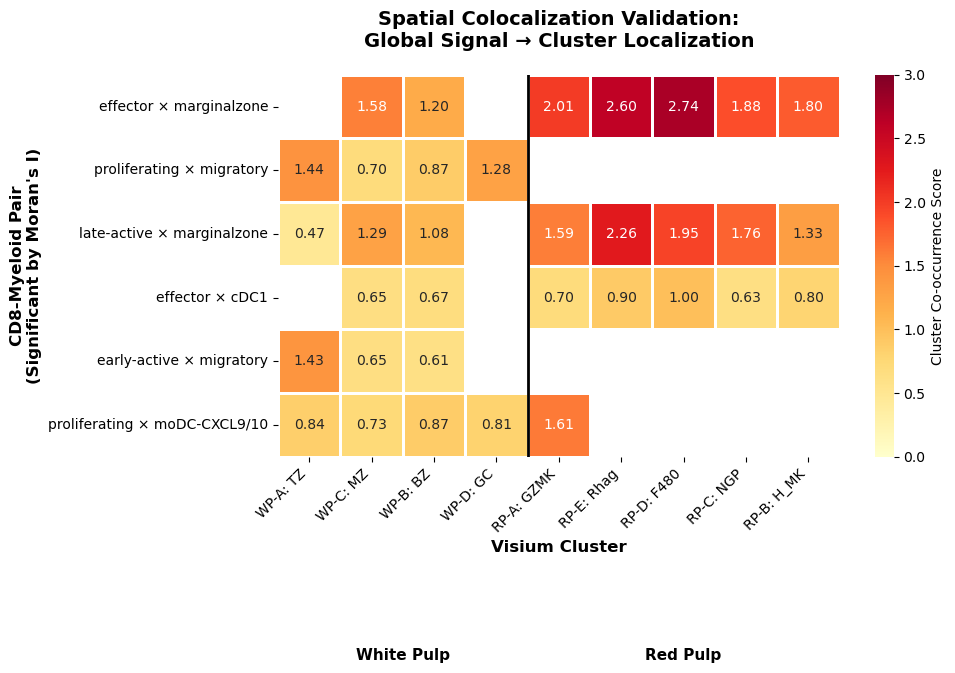

💾 Saved: colocalization_cluster_matches.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("DIRECT COMPARISON: Which pairs colocalize and where?")
print("="*80 + "\n")

# Load data
global_moran = pd.read_csv('global_morans_i_corrected.csv')

# Average across samples
global_avg = global_moran.groupby(['cell_type_1', 'cell_type_2']).agg({
    'I': 'mean',
    'p_value': 'mean'
}).reset_index()

# Define thresholds
MORAN_P_THRESHOLD = 0.05
MORAN_I_THRESHOLD = 0.2  # Positive colocalization
COOC_THRESHOLD = 1.0     # High co-occurrence

# ============================================================================
# STEP 1: Which pairs show significant spatial colocalization?
# ============================================================================

print("STEP 1: Pairs with Significant Spatial Colocalization (Moran's I)")
print("-" * 80)

sig_colocalization = global_avg[
    (global_avg['p_value'] < MORAN_P_THRESHOLD) &
    (global_avg['I'] > MORAN_I_THRESHOLD)
].sort_values('I', ascending=False).copy()

sig_colocalization['cd8_short'] = sig_colocalization['cell_type_1'].str.replace('CD8-Tcell_', '')
sig_colocalization['myeloid_short'] = sig_colocalization['cell_type_2'].str.replace('Myeloid_', '')

print(f"\n{len(sig_colocalization)} pairs with significant positive colocalization (I>{MORAN_I_THRESHOLD}, p<{MORAN_P_THRESHOLD}):\n")
print(sig_colocalization[['cd8_short', 'myeloid_short', 'I', 'p_value']])

# ============================================================================
# STEP 2: For each significant pair, which clusters show high co-occurrence?
# ============================================================================

print("\n" + "="*80)
print("STEP 2: Cluster-Specific Co-occurrence for Significant Pairs")
print("-" * 80)

matches = []

for _, pair in sig_colocalization.iterrows():
    cd8 = pair['cell_type_1']
    myeloid = pair['cell_type_2']
    moran_I = pair['I']
    moran_p = pair['p_value']
    
    # Get cluster co-occurrence for this pair
    pair_clusters = comparison_df[
        (comparison_df['cd8_type'] == cd8) &
        (comparison_df['myeloid_type'] == myeloid)
    ].copy()
    
    # Remove NaN values
    pair_clusters_valid = pair_clusters.dropna(subset=['cluster_cooccurrence'])
    
    # Find clusters with high co-occurrence
    high_cooc_clusters = pair_clusters_valid[
        pair_clusters_valid['cluster_cooccurrence'] > COOC_THRESHOLD
    ].sort_values('cluster_cooccurrence', ascending=False)
    
    cd8_short = cd8.replace('CD8-Tcell_', '')
    myeloid_short = myeloid.replace('Myeloid_', '')
    
    print(f"\n{cd8_short} × {myeloid_short}")
    print(f"  Moran's I = {moran_I:.3f} (p={moran_p:.3f})")
    
    if len(high_cooc_clusters) > 0:
        print(f"  ✓ MATCH: {len(high_cooc_clusters)} clusters with high co-occurrence:")
        for _, row in high_cooc_clusters.iterrows():
            print(f"    - {row['cluster']}: {row['cluster_cooccurrence']:.3f}")
            
            matches.append({
                'cd8': cd8_short,
                'myeloid': myeloid_short,
                'moran_I': moran_I,
                'cluster': row['cluster'],
                'cooccurrence': row['cluster_cooccurrence'],
                'match': 'YES'
            })
    else:
        print(f"  ✗ NO MATCH: No clusters exceed co-occurrence threshold ({COOC_THRESHOLD})")
        
        # Handle case where all values are NaN
        if len(pair_clusters_valid) > 0:
            max_cooc_row = pair_clusters_valid.loc[pair_clusters_valid['cluster_cooccurrence'].idxmax()]
            print(f"    Highest: {max_cooc_row['cluster']} = {max_cooc_row['cluster_cooccurrence']:.3f}")
            
            matches.append({
                'cd8': cd8_short,
                'myeloid': myeloid_short,
                'moran_I': moran_I,
                'cluster': max_cooc_row['cluster'],
                'cooccurrence': max_cooc_row['cluster_cooccurrence'],
                'match': 'NO'
            })
        else:
            print(f"    No valid cluster data (all NaN)")
            matches.append({
                'cd8': cd8_short,
                'myeloid': myeloid_short,
                'moran_I': moran_I,
                'cluster': 'NONE',
                'cooccurrence': np.nan,
                'match': 'NO_DATA'
            })

matches_df = pd.DataFrame(matches)

# ============================================================================
# STEP 3: Summary statistics
# ============================================================================

print("\n" + "="*80)
print("STEP 3: Match Summary")
print("-" * 80)

# Count unique pairs (not individual cluster matches)
pairs_with_matches = matches_df[matches_df['match'] == 'YES'][['cd8', 'myeloid']].drop_duplicates()
n_pairs_with_matches = len(pairs_with_matches)
n_total_significant = len(sig_colocalization)

print(f"\nSignificant colocalization pairs: {n_total_significant}")
print(f"Pairs validated by cluster co-occurrence: {n_pairs_with_matches}")
print(f"Validation rate: {n_pairs_with_matches / n_total_significant * 100:.1f}%")

# Count by cluster type
print("\nClusters driving colocalization:")
cluster_counts = matches_df[matches_df['match'] == 'YES']['cluster'].value_counts()
print(cluster_counts)

# ============================================================================
# STEP 4: Biological interpretation
# ============================================================================

print("\n" + "="*80)
print("STEP 4: Biological Interpretation")
print("-" * 80)

# Categorize clusters
white_pulp = ['WP-A: TZ', 'WP-C: MZ', 'WP-B: BZ', 'WP-D: GC']
red_pulp = ['RP-A: GZMK', 'RP-E: Rhag', 'RP-D: F480', 'RP-C: NGP', 'RP-B: H_MK']

validated_matches = matches_df[matches_df['match'] == 'YES'].copy()
validated_matches['compartment'] = validated_matches['cluster'].apply(
    lambda x: 'White Pulp' if x in white_pulp else 'Red Pulp'
)

print("\nColocalization patterns by tissue compartment:")
print("\nWHITE PULP interactions:")
wp_matches = validated_matches[validated_matches['compartment'] == 'White Pulp']
if len(wp_matches) > 0:
    for (cd8, myeloid), group in wp_matches.groupby(['cd8', 'myeloid']):
        clusters = ', '.join(group['cluster'].tolist())
        print(f"  {cd8} × {myeloid}: {clusters}")
else:
    print("  None")

print("\nRED PULP interactions:")
rp_matches = validated_matches[validated_matches['compartment'] == 'Red Pulp']
if len(rp_matches) > 0:
    for (cd8, myeloid), group in rp_matches.groupby(['cd8', 'myeloid']):
        clusters = ', '.join(group['cluster'].tolist())
        print(f"  {cd8} × {myeloid}: {clusters}")
else:
    print("  None")

# ============================================================================
# VISUALIZATION: Matched pairs heatmap
# ============================================================================

print("\n" + "="*80)
print("Creating validation heatmap...")

# Only include pairs that have at least one match
validated_pairs = validated_matches[['cd8', 'myeloid']].drop_duplicates()

if len(validated_pairs) > 0:
    heatmap_data = []
    pair_labels = []

    for _, pair in validated_pairs.iterrows():
        cd8 = 'CD8-Tcell_' + pair['cd8']
        myeloid = 'Myeloid_' + pair['myeloid']
        
        pair_clusters = comparison_df[
            (comparison_df['cd8_type'] == cd8) &
            (comparison_df['myeloid_type'] == myeloid)
        ].set_index('cluster')['cluster_cooccurrence']
        
        heatmap_data.append(pair_clusters)
        pair_labels.append(f"{pair['cd8']} × {pair['myeloid']}")

    heatmap_matrix = pd.concat(heatmap_data, axis=1).T
    heatmap_matrix.index = pair_labels

    # Order clusters: WP then RP
    cluster_order = ['WP-A: TZ', 'WP-C: MZ', 'WP-B: BZ', 'WP-D: GC',
                     'RP-A: GZMK', 'RP-E: Rhag', 'RP-D: F480', 'RP-C: NGP', 'RP-B: H_MK']
    heatmap_matrix = heatmap_matrix[[c for c in cluster_order if c in heatmap_matrix.columns]]

    fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        heatmap_matrix,
        cmap='YlOrRd',
        annot=True,
        fmt='.2f',
        cbar_kws={'label': 'Cluster Co-occurrence Score'},
        linewidths=1,
        linecolor='white',
        ax=ax,
        vmin=0,
        vmax=3
    )

    # Add vertical line separating WP and RP
    wp_cols = [c for c in cluster_order[:4] if c in heatmap_matrix.columns]
    if len(wp_cols) < len(heatmap_matrix.columns):
        ax.axvline(x=len(wp_cols), color='black', linewidth=2)

    # Add text labels
    ax.text(len(wp_cols)/2, -0.5, 'White Pulp', ha='center', va='top', 
            fontsize=11, fontweight='bold', transform=ax.get_xaxis_transform())
    ax.text(len(wp_cols) + (len(heatmap_matrix.columns) - len(wp_cols))/2, -0.5, 'Red Pulp', 
            ha='center', va='top', fontsize=11, fontweight='bold', transform=ax.get_xaxis_transform())

    ax.set_xlabel('Visium Cluster', fontsize=12, fontweight='bold')
    ax.set_ylabel('CD8-Myeloid Pair\n(Significant by Moran\'s I)', fontsize=12, fontweight='bold')
    ax.set_title('Spatial Colocalization Validation:\nGlobal Signal → Cluster Localization', 
                 fontsize=14, fontweight='bold', pad=20)

    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()

    plt.savefig('colocalization_validation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig('colocalization_validation_heatmap.pdf', bbox_inches='tight')
    print("📊 Saved: colocalization_validation_heatmap.png/pdf")
    plt.show()
else:
    print("No validated pairs to visualize")

# Save results table
matches_df.to_csv('colocalization_cluster_matches.csv', index=False)
print("💾 Saved: colocalization_cluster_matches.csv")

ABUNDANCE ANALYSIS: CD8 and Myeloid Cell Types per Cluster

CD8 T CELL ABUNDANCES BY CLUSTER

Mean abundances (cells per spot):

cell_type   Early-Active  Effector  Late-Active  Naive  Proliferating
cluster                                                              
RP-A: GZMK         0.271     0.392        0.274  0.296          0.369
RP-B: H_MK         0.204     0.317        0.227  0.214          0.243
RP-C: NGP          0.248     0.329        0.240  0.272          0.329
RP-D: F480         0.322     0.522        0.332  0.377          0.377
RP-E: Rhag         0.226     0.396        0.246  0.295          0.282
WP-A: TZ           0.959     0.164        0.213  1.004          0.815
WP-B: BZ           0.342     0.243        0.228  0.289          0.609
WP-C: MZ           0.349     0.383        0.306  0.343          0.510
WP-D: GC           0.176     0.062        0.073  0.175          1.160

MYELOID CELL ABUNDANCES BY CLUSTER

Mean abundances (cells per spot):

cell_type   Mac-A  Mac-B  Mac

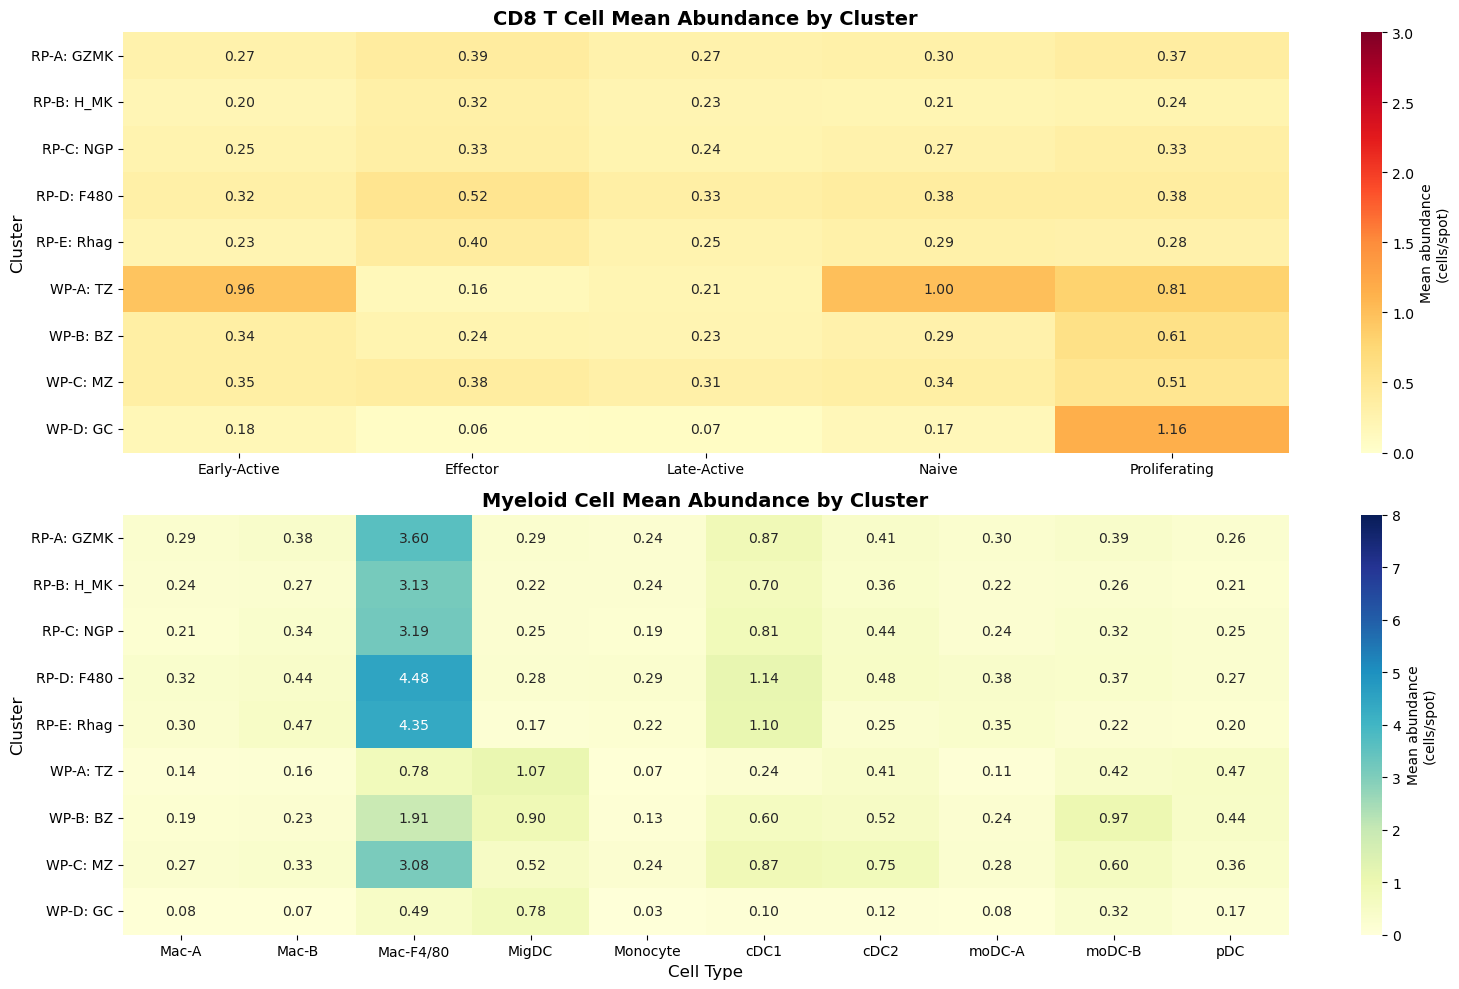


THRESHOLD ANALYSIS

Percentage of spots above different thresholds:

CD8 T Cells:
%-spots > 0.2 cells/spot:
cell_type   Early-Active  Effector  Late-Active  Naive  Proliferating
cluster                                                              
RP-A: GZMK          82.0      89.7         79.9   86.6           94.8
RP-B: H_MK          52.0      73.3         60.0   56.0           53.3
RP-C: NGP           71.1      74.4         62.2   77.8           82.2
RP-D: F480          95.0      98.3         92.4   96.6           99.2
RP-E: Rhag          63.5      88.3         70.3   77.0           80.2
WP-A: TZ           100.0      21.6         50.0  100.0           98.6
WP-B: BZ            94.5      57.5         58.9   84.5           99.5
WP-C: MZ            97.1      93.0         93.0   97.5          100.0
WP-D: GC            39.4       0.0          0.0   33.3          100.0

%-spots > 1.0 cells/spot:
cell_type   Early-Active  Effector  Late-Active  Naive  Proliferating
cluster                 

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*80)
print("ABUNDANCE ANALYSIS: CD8 and Myeloid Cell Types per Cluster")
print("="*80 + "\n")

# Load data
infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
adata_infected = sc.read_h5ad(infected_path)

# CD8 types - EXCLUDING TERMINAL
conventional_cd8 = [
    'CD8-Tcell_naive', 'CD8-Tcell_early-active', 'CD8-Tcell_effector',
    'CD8-Tcell_late-active', 'CD8-Tcell_proliferating'
]

myeloid_types = [ct for ct in adata_infected.obsm['means_cell_abundance_w_sf'].columns 
                 if 'Myeloid' in ct]

name_mapping = {
    'Myeloid_DC2': 'Myeloid_cDC2',
    'Myeloid_Macrophage': 'Myeloid_Mac-A',
    'Myeloid_Macrophage-CXCL9/10': 'Myeloid_Mac-B',
    'Myeloid_cDC1': 'Myeloid_cDC1',
    'Myeloid_marginalzone': 'Myeloid_Mac-F4/80',
    'Myeloid_migratory': 'Myeloid_MigDC',
    'Myeloid_moDC': 'Myeloid_moDC-A',
    'Myeloid_moDC-CXCL9/10': 'Myeloid_moDC-B',
    'Myeloid_monocyte': 'Myeloid_Monocyte',
    'Myeloid_pDC': 'Myeloid_pDC',
}

cluster_order = ['WP-A: TZ', 'WP-C: MZ', 'WP-B: BZ', 'WP-D: GC',
                 'RP-A: GZMK', 'RP-E: Rhag', 'RP-D: F480', 'RP-C: NGP', 'RP-B: H_MK']

# Calculate mean abundances per cluster
cd8_abundance_data = []
myeloid_abundance_data = []

for cluster in cluster_order:
    cluster_data = adata_infected[adata_infected.obs['paper_clusters'] == cluster]
    abundances = cluster_data.obsm['means_cell_abundance_w_sf']
    
    # CD8 abundances
    for cd8 in conventional_cd8:
        if cd8 in abundances.columns:
            cd8_name = cd8.replace('CD8-Tcell_', '').replace('_', '-').title()
            cd8_abundance_data.append({
                'cluster': cluster,
                'cell_type': cd8_name,
                'mean_abundance': abundances[cd8].mean(),
                'median_abundance': abundances[cd8].median(),
                'max_abundance': abundances[cd8].max(),
                'pct_above_0.2': (abundances[cd8] > 0.2).mean() * 100,
                'pct_above_0.5': (abundances[cd8] > 0.5).mean() * 100,
                'pct_above_1.0': (abundances[cd8] > 1.0).mean() * 100,
            })
    
    # Myeloid abundances
    for myeloid in myeloid_types:
        if myeloid in abundances.columns:
            myeloid_name = name_mapping.get(myeloid, myeloid).replace('Myeloid_', '')
            myeloid_abundance_data.append({
                'cluster': cluster,
                'cell_type': myeloid_name,
                'mean_abundance': abundances[myeloid].mean(),
                'median_abundance': abundances[myeloid].median(),
                'max_abundance': abundances[myeloid].max(),
                'pct_above_0.2': (abundances[myeloid] > 0.2).mean() * 100,
                'pct_above_0.5': (abundances[myeloid] > 0.5).mean() * 100,
                'pct_above_1.0': (abundances[myeloid] > 1.0).mean() * 100,
            })

cd8_df = pd.DataFrame(cd8_abundance_data)
myeloid_df = pd.DataFrame(myeloid_abundance_data)

print("="*80)
print("CD8 T CELL ABUNDANCES BY CLUSTER")
print("="*80)
print("\nMean abundances (cells per spot):\n")
cd8_pivot = cd8_df.pivot(index='cluster', columns='cell_type', values='mean_abundance')
print(cd8_pivot.round(3))

print("\n" + "="*80)
print("MYELOID CELL ABUNDANCES BY CLUSTER")
print("="*80)
print("\nMean abundances (cells per spot):\n")
myeloid_pivot = myeloid_df.pivot(index='cluster', columns='cell_type', values='mean_abundance')
print(myeloid_pivot.round(3))

# Create heatmaps
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# CD8 heatmap
sns.heatmap(
    cd8_pivot,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Mean abundance\n(cells/spot)'},
    ax=axes[0],
    vmin=0,
    vmax=3
)
axes[0].set_title('CD8 T Cell Mean Abundance by Cluster', fontsize=14, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Cluster', fontsize=12)

# Myeloid heatmap
sns.heatmap(
    myeloid_pivot,
    cmap='YlGnBu',
    annot=True,
    fmt='.2f',
    cbar_kws={'label': 'Mean abundance\n(cells/spot)'},
    ax=axes[1],
    vmin=0,
    vmax=8
)
axes[1].set_title('Myeloid Cell Mean Abundance by Cluster', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cell Type', fontsize=12)
axes[1].set_ylabel('Cluster', fontsize=12)

plt.tight_layout()
plt.savefig('abundance_heatmaps_by_cluster.png', dpi=300, bbox_inches='tight')
plt.savefig('abundance_heatmaps_by_cluster.pdf', bbox_inches='tight')
print("\n📊 Saved: abundance_heatmaps_by_cluster.png/pdf")
plt.show()

# Distribution analysis for threshold selection
print("\n" + "="*80)
print("THRESHOLD ANALYSIS")
print("="*80)
print("\nPercentage of spots above different thresholds:\n")

print("CD8 T Cells:")
print("%-spots > 0.2 cells/spot:")
cd8_threshold_02 = cd8_df.pivot(index='cluster', columns='cell_type', values='pct_above_0.2')
print(cd8_threshold_02.round(1))

print("\n%-spots > 1.0 cells/spot:")
cd8_threshold_10 = cd8_df.pivot(index='cluster', columns='cell_type', values='pct_above_1.0')
print(cd8_threshold_10.round(1))

print("\n" + "-"*80)
print("\nMyeloid Cells:")
print("%-spots > 0.2 cells/spot:")
myeloid_threshold_02 = myeloid_df.pivot(index='cluster', columns='cell_type', values='pct_above_0.2')
print(myeloid_threshold_02.round(1))

print("\n%-spots > 1.0 cells/spot:")
myeloid_threshold_10 = myeloid_df.pivot(index='cluster', columns='cell_type', values='pct_above_1.0')
print(myeloid_threshold_10.round(1))

print("\n" + "="*80)
print("THRESHOLD RECOMMENDATIONS")
print("="*80)
print("""
Based on abundance distributions:

Current asymmetric threshold:
  - Both > 0.2 cells/spot (detection threshold)
  - At least one > 1.0 cells/spot (enrichment threshold)

This filters:
  - CD8/Myeloid pairs where both are just background noise (~0.2-0.4)
  - Keeps cases where at least one cell type is genuinely enriched

Alternative thresholds to consider:
  - More permissive: Both > 0.2, at least one > 0.5
  - More strict: Both > 0.3, at least one > 1.5
  - Cell-type specific: Different thresholds for CD8 vs Myeloid
""")

print("="*80)
print("COMPLETE")
print("="*80)

In [ ]:
import scanpy as sc
import numpy as np

infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
adata_infected = sc.read_h5ad(infected_path)

# Check if there's scale information
print("Checking for spatial scale metadata...")
if 'spatial' in adata_infected.uns:
    print("\nadata.uns['spatial'] contents:")
    for key, value in adata_infected.uns['spatial'].items():
        print(f"  {key}: {type(value)}")
        if isinstance(value, dict):
            for k2, v2 in value.items():
                print(f"    {k2}: {v2 if not isinstance(v2, np.ndarray) else 'array'}")

# Sample coordinates
sample = 'V1S1'
mask = (adata_infected.obs['sample'] == sample).values
coords = adata_infected.obsm['spatial'][mask]

# Find truly adjacent spots (minimum distance pairs)
from scipy.spatial.distance import pdist, squareform
distances = squareform(pdist(coords))
np.fill_diagonal(distances, np.inf)

min_distances = []
for i in range(min(100, len(coords))):  # Sample first 100 spots
    min_dist = distances[i].min()
    if min_dist < np.inf:
        min_distances.append(min_dist)

min_distances = np.array(min_distances)

print(f"\nMinimum distances between spots (coordinate units):")
print(f"  Minimum: {min_distances.min():.1f}")
print(f"  Median: {np.median(min_distances):.1f}")
print(f"  Mean: {min_distances.mean():.1f}")

print("\n" + "="*80)
print("COORDINATE TO MICRON CONVERSION")
print("="*80)
print("For standard Visium:")
print("  - Adjacent spots = 100 microns center-to-center")
print(f"  - Your adjacent spots = {np.median(min_distances):.1f} coordinate units")
print(f"  - Conversion: 1 coordinate unit = {100 / np.median(min_distances):.3f} microns")
print(f"  - Therefore: 500 units = {300 * (100 / np.median(min_distances)):.1f} microns")
print("="*80)

print("\nRECOMMENDATION:")
adjacent_units = np.median(min_distances)
print(f"Use radius = {adjacent_units * 1.5:.0f} units (≈150 microns, immediate neighbors)")
print(f"Or radius = {adjacent_units * 2.5:.0f} units (≈250 microns, includes 2nd order neighbors)")

Checking for spatial scale metadata...

adata.uns['spatial'] contents:
  Spleen_Visium_Exp3A_V1S1_3wk_infected: <class 'dict'>
    images: {'hires': array([[[253, 252, 251],
        [253, 252, 251],
        [252, 252, 251],
        ...,
        [252, 253, 251],
        [252, 252, 251],
        [252, 252, 251]],

       [[253, 252, 251],
        [252, 252, 251],
        [252, 252, 251],
        ...,
        [252, 252, 252],
        [252, 252, 252],
        [252, 252, 251]],

       [[252, 252, 251],
        [252, 252, 251],
        [253, 252, 251],
        ...,
        [253, 252, 252],
        [252, 253, 251],
        [253, 252, 251]],

       ...,

       [[252, 253, 253],
        [253, 253, 252],
        [252, 252, 252],
        ...,
        [253, 253, 251],
        [253, 253, 251],
        [253, 252, 251]],

       [[253, 253, 252],
        [253, 253, 252],
        [253, 253, 252],
        ...,
        [253, 252, 251],
        [253, 252, 252],
        [253, 252, 252]],

       [[253,

In [ ]:
from scipy.sparse import csr_matrix
import numpy as np
import pandas as pd
import scanpy as sc

print("="*80)
print("DETAILED NEIGHBOR VERIFICATION")
print("="*80)
print("Checking individual spots to verify same-cluster neighbor detection")
print("="*80 + "\n")

infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
adata_infected = sc.read_h5ad(infected_path)

# Focus on GC in V1S1 since you're suspicious of it
sample = 'V1S1'
target_cluster = 'WP-D: GC'

print(f"Examining: {target_cluster} in {sample}\n")

mask = (adata_infected.obs['sample'] == sample).values
indices = np.where(mask)[0]
clusters = adata_infected.obs['paper_clusters'].iloc[indices]

# Get adjacency matrix
adj_matrix = adata_infected.obsp['connectivities']
if not isinstance(adj_matrix, csr_matrix):
    adj_matrix = csr_matrix(adj_matrix)
adj_sub = adj_matrix[mask, :][:, mask]

# Get GC spots
gc_mask = (clusters == target_cluster).values
gc_indices = np.where(gc_mask)[0]

print(f"Total {target_cluster} spots: {len(gc_indices)}\n")
print("Detailed breakdown of first 10 spots:")
print("-" * 80)

for i, spot_idx in enumerate(gc_indices[:10]):
    # Get all spatial neighbors
    neighbor_indices = adj_sub[spot_idx].nonzero()[1]
    
    # Check cluster of each neighbor
    neighbor_clusters = [clusters.iloc[n] for n in neighbor_indices]
    
    # Count same-cluster neighbors
    same_cluster_count = sum(1 for c in neighbor_clusters if c == target_cluster)
    other_cluster_count = len(neighbor_clusters) - same_cluster_count
    
    print(f"\nSpot {i+1} (index {spot_idx}):")
    print(f"  Total neighbors: {len(neighbor_indices)}")
    print(f"  Same cluster ({target_cluster}): {same_cluster_count}")
    print(f"  Other clusters: {other_cluster_count}")
    
    if other_cluster_count > 0:
        other_cluster_names = [c for c in neighbor_clusters if c != target_cluster]
        cluster_counts = pd.Series(other_cluster_names).value_counts()
        print(f"  Other cluster breakdown:")
        for cluster, count in cluster_counts.items():
            print(f"    {cluster}: {count}")

print("\n" + "="*80)
print("SUMMARY FOR ALL SPOTS")
print("="*80)

summary_data = []

for spot_idx in gc_indices:
    neighbor_indices = adj_sub[spot_idx].nonzero()[1]
    neighbor_clusters = [clusters.iloc[n] for n in neighbor_indices]
    
    same_cluster_count = sum(1 for c in neighbor_clusters if c == target_cluster)
    total_neighbors = len(neighbor_indices)
    pct_same = (same_cluster_count / total_neighbors * 100) if total_neighbors > 0 else 0
    
    summary_data.append({
        'spot_idx': spot_idx,
        'total_neighbors': total_neighbors,
        'same_cluster_neighbors': same_cluster_count,
        'other_cluster_neighbors': total_neighbors - same_cluster_count,
        'pct_same_cluster': pct_same
    })

df_summary = pd.DataFrame(summary_data)

print(f"\nDistribution of same-cluster neighbor counts:")
print(df_summary['same_cluster_neighbors'].value_counts().sort_index())

print(f"\nSpots with 0 same-cluster neighbors: {(df_summary['same_cluster_neighbors'] == 0).sum()}")
print(f"Spots with 1-3 same-cluster neighbors: {((df_summary['same_cluster_neighbors'] >= 1) & (df_summary['same_cluster_neighbors'] <= 3)).sum()}")
print(f"Spots with 4+ same-cluster neighbors: {(df_summary['same_cluster_neighbors'] >= 4).sum()}")

print(f"\nMean % of neighbors that are same cluster: {df_summary['pct_same_cluster'].mean():.1f}%")
print(f"Median % of neighbors that are same cluster: {df_summary['pct_same_cluster'].median():.1f}%")

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("If most GC spots have 50%+ same-cluster neighbors, then GC might actually")
print("form local spatial clusters even though the overall tissue is interdigitated.")
print("\nIf most GC spots have <20% same-cluster neighbors, then there's a problem")
print("with how the analysis is identifying 'connected' spots.")
print("="*80)


DETAILED NEIGHBOR VERIFICATION
Checking individual spots to verify same-cluster neighbor detection

Examining: WP-D: GC in V1S1

Total WP-D: GC spots: 18

Detailed breakdown of first 10 spots:
--------------------------------------------------------------------------------

Spot 1 (index 43):
  Total neighbors: 21
  Same cluster (WP-D: GC): 17
  Other clusters: 4
  Other cluster breakdown:
    WP-B: BZ: 4

Spot 2 (index 72):
  Total neighbors: 8
  Same cluster (WP-D: GC): 8
  Other clusters: 0

Spot 3 (index 78):
  Total neighbors: 15
  Same cluster (WP-D: GC): 10
  Other clusters: 5
  Other cluster breakdown:
    WP-B: BZ: 5

Spot 4 (index 145):
  Total neighbors: 9
  Same cluster (WP-D: GC): 8
  Other clusters: 1
  Other cluster breakdown:
    WP-B: BZ: 1

Spot 5 (index 167):
  Total neighbors: 10
  Same cluster (WP-D: GC): 6
  Other clusters: 4
  Other cluster breakdown:
    WP-B: BZ: 4

Spot 6 (index 289):
  Total neighbors: 19
  Same cluster (WP-D: GC): 15
  Other clusters: 4
  Ot

In [ ]:
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix

print("="*80)
print("CHECKING SPATIAL NEIGHBOR PARAMETERS")
print("="*80 + "\n")

infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
adata_infected = sc.read_h5ad(infected_path)

# Check if there's metadata about how neighbors were computed
print("Checking adata.uns for spatial neighbor info:")
if 'spatial_neighbors' in adata_infected.uns:
    print(adata_infected.uns['spatial_neighbors'])
else:
    print("No spatial neighbor metadata found in adata.uns")

# Manually calculate distances between connected neighbors
sample = 'V1S1'
mask = (adata_infected.obs['sample'] == sample).values
spatial_coords = adata_infected.obsm['spatial'][mask]

adj_matrix = adata_infected.obsp['connectivities']
if not isinstance(adj_matrix, csr_matrix):
    adj_matrix = csr_matrix(adj_matrix)
adj_sub = adj_matrix[mask, :][:, mask]

print("\n" + "="*80)
print("MEASURING ACTUAL DISTANCES BETWEEN CONNECTED NEIGHBORS")
print("="*80)

# Sample 100 random spots and measure distances to their neighbors
sample_size = min(100, adj_sub.shape[0])
sample_indices = np.random.choice(adj_sub.shape[0], sample_size, replace=False)

all_distances = []

for spot_idx in sample_indices:
    neighbor_indices = adj_sub[spot_idx].nonzero()[1]
    
    spot_coord = spatial_coords[spot_idx]
    
    for neighbor_idx in neighbor_indices:
        neighbor_coord = spatial_coords[neighbor_idx]
        distance = np.linalg.norm(spot_coord - neighbor_coord)
        all_distances.append(distance)

all_distances = np.array(all_distances)

print(f"\nSampled {sample_size} spots and their neighbors")
print(f"Total neighbor connections analyzed: {len(all_distances)}")
print(f"\nDistance statistics (in coordinate units):")
print(f"  Min distance: {all_distances.min():.1f}")
print(f"  Max distance: {all_distances.max():.1f}")
print(f"  Mean distance: {all_distances.mean():.1f}")
print(f"  Median distance: {np.median(all_distances):.1f}")
print(f"  25th percentile: {np.percentile(all_distances, 25):.1f}")
print(f"  75th percentile: {np.percentile(all_distances, 75):.1f}")

print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("Visium spatial coordinates are typically in pixel units.")
print("If these distances are ~100-200 units, neighbors are immediate adjacents.")
print("If distances are ~500-1000 units, neighbors include more distant spots.")
print("\nFor Visium: ~100 microns center-to-center = immediately adjacent spots")
print("="*80)

# Check coordinate scale
print(f"\nSpatial coordinate range:")
print(f"  X: {spatial_coords[:, 0].min():.0f} to {spatial_coords[:, 0].max():.0f}")
print(f"  Y: {spatial_coords[:, 1].min():.0f} to {spatial_coords[:, 1].max():.0f}")

# Estimate micron scale
print("\n" + "="*80)
print("ESTIMATING MICRON SCALE")
print("="*80)
print("Visium HD has 2-micron bin size, standard Visium has 100-micron center-to-center spacing")
print("If your neighbor distances are ~100-200 coordinate units,")
print("this likely corresponds to ~100-200 microns (immediately adjacent spots)")
print("="*80)

CHECKING SPATIAL NEIGHBOR PARAMETERS

Checking adata.uns for spatial neighbor info:
{'connectivities_key': 'spatial_connectivities', 'distances_key': 'spatial_distances', 'params': {'coord_type': 'grid', 'n_neighbors': 6}}

MEASURING ACTUAL DISTANCES BETWEEN CONNECTED NEIGHBORS

Sampled 100 spots and their neighbors
Total neighbor connections analyzed: 888

Distance statistics (in coordinate units):
  Min distance: 289.0
  Max distance: 10340.7
  Mean distance: 3245.7
  Median distance: 3034.9
  25th percentile: 1532.1
  75th percentile: 4658.3

INTERPRETATION
Visium spatial coordinates are typically in pixel units.
If these distances are ~100-200 units, neighbors are immediate adjacents.
If distances are ~500-1000 units, neighbors include more distant spots.

For Visium: ~100 microns center-to-center = immediately adjacent spots

Spatial coordinate range:
  X: 11420 to 18712
  Y: 2212 to 11924

ESTIMATING MICRON SCALE
Visium HD has 2-micron bin size, standard Visium has 100-micron cen

In [ ]:
# Now let's extract expression data and map to paper names
print("Extracting expression data with paper name mapping...\n")

# Myeloid types in this file
myeloid_types_current = [
    'Myeloid_monocyte',
    'Myeloid_Macrophage',
    'Myeloid_moDC',
    'Myeloid_migratory',
    'Myeloid_DC2',
    'Myeloid_Macrophage-CXCL9/10',
    'Myeloid_pDC',
    'Myeloid_cDC1',
    'Myeloid_marginalzone',
    'Myeloid_moDC-CXCL9/10'
]

# Mapping to paper display names
name_mapping_for_display = {
    'Myeloid_monocyte': 'Monocyte',
    'Myeloid_Macrophage': 'Mac-A',
    'Myeloid_moDC': 'moDC-A',
    'Myeloid_migratory': 'MigDC',
    'Myeloid_DC2': 'cDC2',
    'Myeloid_Macrophage-CXCL9/10': 'Mac-B',
    'Myeloid_pDC': 'pDC',
    'Myeloid_cDC1': 'cDC1',
    'Myeloid_marginalzone': 'Mac-F480',
    'Myeloid_moDC-CXCL9/10': 'moDC-B'
}

# Filter for myeloid cells
adata_myeloid_new = adata_sc_new[adata_sc_new.obs['celltypes_redo'].isin(myeloid_types_current)].copy()
print(f"Myeloid cells: {adata_myeloid_new.shape[0]}")

# EXACT gene order from reference
gene_order = [
    'Il1b', 'Csf3r', 'S100a8', 'S100a9', 'Ccl9', 'Ccr2',
    'F13a1', 'Fn1', 'Chil3', 'Plcb1', 'Il27', 'Ace', 'Ear2', 'Cxcl16',
    'H2-M2', 'Ccl5', 'Cacnb3', 'Ccr7', 'Clec4a4', 'Ifng', 'Mgl2', 'Ccr5', 'Siglech', 'Tcf4',
    'Clec9a', 'Tlr3', 'Xcr1', 'Cxcl9', 'Adgre1', 'Il18',
    'Mrc1', 'C1qc', 'Cd5l', 'Vcam1', 'Cxcl10', 'Mmp14'
]

# Check which genes are present
genes_present = [g for g in gene_order if g in adata_myeloid_new.var_names]
genes_missing = [g for g in gene_order if g not in adata_myeloid_new.var_names]

print(f"\nGenes present: {len(genes_present)}/{len(gene_order)}")
if genes_missing:
    print(f"Missing genes: {genes_missing}")

# Subset to genes of interest
adata_subset_new = adata_myeloid_new[:, genes_present].copy()

# Calculate mean expression per cell type
print("\nCalculating mean expression per cell type...")
expr_matrix = []
cell_type_labels = []

for cell_type in myeloid_types_current:
    cells_mask = adata_subset_new.obs['celltypes_redo'] == cell_type
    cells = adata_subset_new[cells_mask]
    
    if cells.shape[0] > 0:
        # Get expression matrix
        if hasattr(cells.X, 'toarray'):
            X = cells.X.toarray()
        else:
            X = cells.X
        
        # Calculate mean
        mean_expr = X.mean(axis=0)
        expr_matrix.append(mean_expr)
        
        # Use paper name for display
        cell_type_labels.append(name_mapping_for_display[cell_type])

# Create dataframe
expr_df_new = pd.DataFrame(
    expr_matrix,
    index=cell_type_labels,
    columns=genes_present
)

# Z-score normalize
from scipy.stats import zscore
expr_df_new_norm = expr_df_new.apply(zscore, axis=0)

print(f"\nExpression matrix: {expr_df_new_norm.shape}")
print(f"Cell types: {expr_df_new_norm.index.tolist()}")

print("\n✅ Data ready with correct names!")

Extracting expression data with paper name mapping...

Myeloid cells: 13168

Genes present: 36/36

Calculating mean expression per cell type...

Expression matrix: (10, 36)
Cell types: ['Monocyte', 'Mac-A', 'moDC-A', 'MigDC', 'cDC2', 'Mac-B', 'pDC', 'cDC1', 'Mac-F480', 'moDC-B']

✅ Data ready with correct names!


In [ ]:
# Z-score within each condition separately
from scipy.stats import zscore

expr_df_inf_norm = expr_df_inf.apply(zscore, axis=0)
expr_df_uninf_norm = expr_df_uninf.apply(zscore, axis=0)

# Use consistent color limits
vmin, vmax = -1, 2.5

📊 Saved: myeloid_gene_expression_INFECTED_zscore.png/pdf


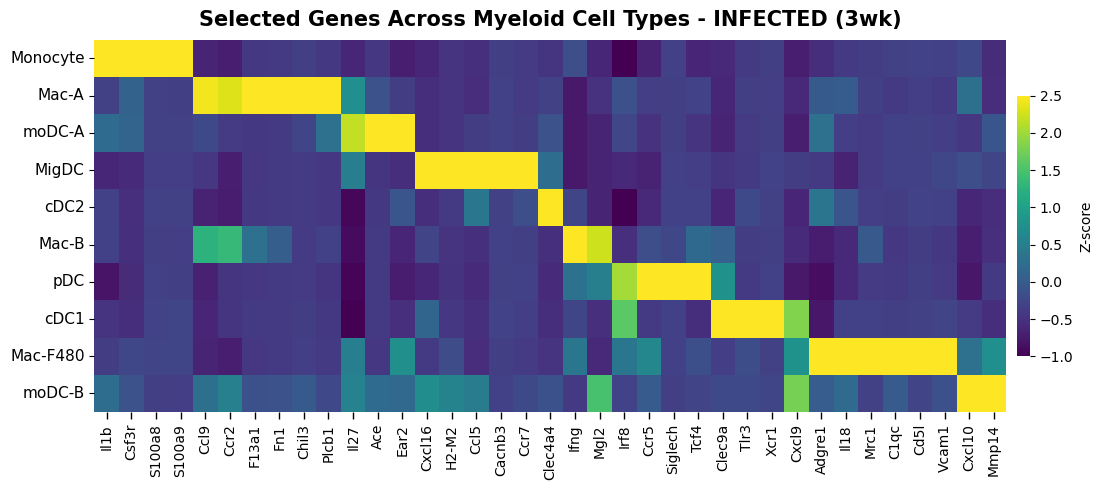

In [ ]:
# Plot INFECTED
expr_ordered = expr_df_inf_norm.reindex(index=cell_type_order, columns=genes_present)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(expr_ordered, cmap='viridis', vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Z-score', 'shrink': 0.7, 'pad': 0.01},
            linewidths=0.001, linecolor='white', ax=ax,
            yticklabels=True, xticklabels=True)
ax.set_title('Selected Genes Across Myeloid Cell Types - INFECTED (3wk)', 
             fontsize=15, fontweight='bold', pad=10)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)
ax.tick_params(axis='x', which='major', length=5, width=1, direction='out', bottom=True)
plt.tight_layout()
plt.savefig('myeloid_gene_expression_INFECTED_zscore.png', dpi=300, bbox_inches='tight')
plt.savefig('myeloid_gene_expression_INFECTED_zscore.pdf', bbox_inches='tight')
print("📊 Saved: myeloid_gene_expression_INFECTED_zscore.png/pdf")
plt.show()

📊 Saved: myeloid_gene_expression_UNINFECTED_zscore.png/pdf


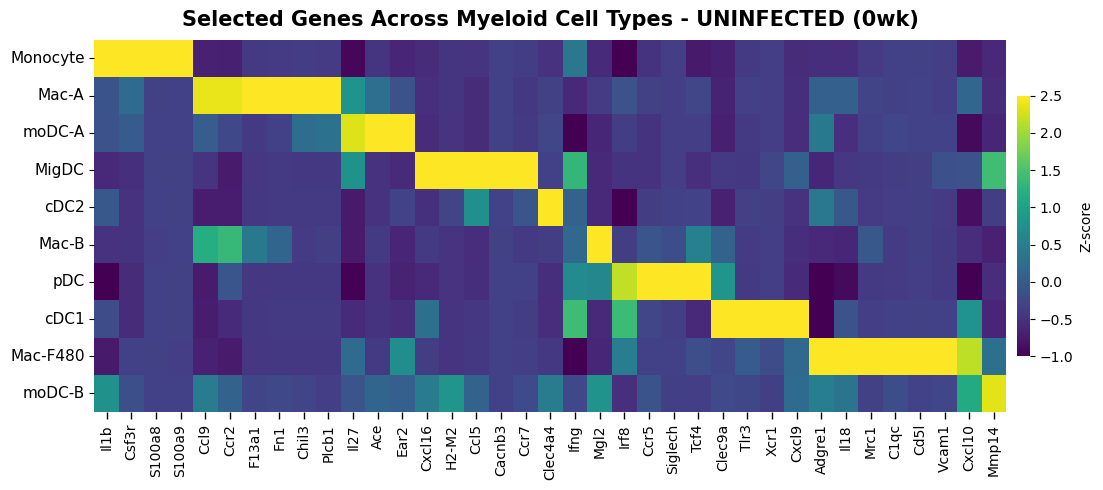

In [ ]:
# Plot UNINFECTED
expr_ordered = expr_df_uninf_norm.reindex(index=cell_type_order, columns=genes_present)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(expr_ordered, cmap='viridis', vmin=vmin, vmax=vmax,
            cbar_kws={'label': 'Z-score', 'shrink': 0.7, 'pad': 0.01},
            linewidths=0.001, linecolor='white', ax=ax,
            yticklabels=True, xticklabels=True)
ax.set_title('Selected Genes Across Myeloid Cell Types - UNINFECTED (0wk)', 
             fontsize=15, fontweight='bold', pad=10)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)
ax.tick_params(axis='x', which='major', length=5, width=1, direction='out', bottom=True)
plt.tight_layout()
plt.savefig('myeloid_gene_expression_UNINFECTED_zscore.png', dpi=300, bbox_inches='tight')
plt.savefig('myeloid_gene_expression_UNINFECTED_zscore.pdf', bbox_inches='tight')
print("📊 Saved: myeloid_gene_expression_UNINFECTED_zscore.png/pdf")
plt.show()

📊 Saved: myeloid_gene_expression_FOLDCHANGE.png/pdf


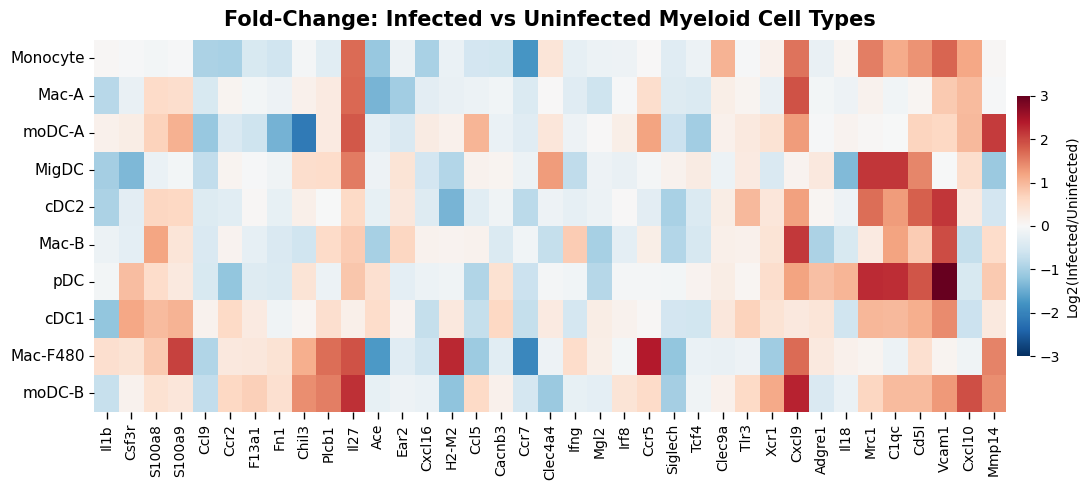


Fold-change heatmap legend:
  Red = higher in INFECTED
  Blue = higher in UNINFECTED
  White = no change


In [ ]:
# Calculate fold-change (log2)
import numpy as np

# Add pseudocount to avoid division by zero
expr_df_fc = np.log2((expr_df_inf + 0.01) / (expr_df_uninf + 0.01))

# Reorder
expr_df_fc_ordered = expr_df_fc.reindex(index=cell_type_order, columns=genes_present)

# Plot fold-change heatmap
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(expr_df_fc_ordered, cmap='RdBu_r', center=0, vmin=-3, vmax=3,
            cbar_kws={'label': 'Log2(Infected/Uninfected)', 'shrink': 0.7, 'pad': 0.01},
            linewidths=0.001, linecolor='white', ax=ax,
            yticklabels=True, xticklabels=True)
ax.set_title('Fold-Change: Infected vs Uninfected Myeloid Cell Types', 
             fontsize=15, fontweight='bold', pad=10)
plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)
ax.tick_params(axis='x', which='major', length=5, width=1, direction='out', bottom=True)
plt.tight_layout()
plt.savefig('myeloid_gene_expression_FOLDCHANGE.png', dpi=300, bbox_inches='tight')
plt.savefig('myeloid_gene_expression_FOLDCHANGE.pdf', bbox_inches='tight')
print("📊 Saved: myeloid_gene_expression_FOLDCHANGE.png/pdf")
plt.show()

print("\nFold-change heatmap legend:")
print("  Red = higher in INFECTED")
print("  Blue = higher in UNINFECTED")
print("  White = no change")

In [ ]:
# Compare expression per cell type between infected and uninfected
print("GENE EXPRESSION COMPARISON BY CELL TYPE\n")

# Pick a few example genes and cell types
test_genes = [
    'Il1b', 'Csf3r', 'S100a8', 'S100a9', 'Ccl9', 'Ccr2',
    'F13a1', 'Fn1', 'Chil3', 'Plcb1', 'Il27', 'Ace', 'Ear2', 'Cxcl16',
    'H2-M2', 'Ccl5', 'Cacnb3', 'Ccr7', 'Clec4a4', 'Ifng', 'Mgl2', 'Ccr5', 'Siglech', 'Tcf4',
    'Clec9a', 'Tlr3', 'Xcr1', 'Cxcl9', 'Adgre1', 'Il18',
    'Mrc1', 'C1qc', 'Cd5l', 'Vcam1', 'Cxcl10', 'Mmp14'
]
test_cell_types = ['Monocyte', 'Mac-A', 'pDC', 'Mac-F480', 'moDC-A', 'MigDC', 'cDC2', 'Mac-B', 'moDC-B']

print(f"{'Gene':<10} {'Cell Type':<12} {'Infected':<10} {'Uninfected':<10} {'Ratio':<8}")
print("-" * 60)

for gene in test_genes:
    for ct in test_cell_types:
        if gene in genes_present:
            inf_val = expr_df_inf.loc[ct, gene]
            uninf_val = expr_df_uninf.loc[ct, gene]
            ratio = inf_val / uninf_val if uninf_val > 0 else float('inf')
            print(f"{gene:<10} {ct:<12} {inf_val:<10.3f} {uninf_val:<10.3f} {ratio:<8.2f}")
    print()

# Or show full comparison for one gene
print("\n" + "="*60)
print("FULL COMPARISON - Cd5l (infection-responsive gene)")
print("="*60)
gene = 'Cd5l'
comparison_df = pd.DataFrame({
    'Infected': expr_df_inf[gene].reindex(cell_type_order),
    'Uninfected': expr_df_uninf[gene].reindex(cell_type_order),
})
comparison_df['Fold-change'] = comparison_df['Infected'] / comparison_df['Uninfected']
print(comparison_df.round(3))

GENE EXPRESSION COMPARISON BY CELL TYPE

Gene       Cell Type    Infected   Uninfected Ratio   
------------------------------------------------------------
Il1b       Monocyte     3.318      3.227      1.03    
Il1b       Mac-A        0.480      0.863      0.56    
Il1b       pDC          0.033      0.036      0.93    
Il1b       Mac-F480     0.433      0.304      1.43    
Il1b       moDC-A       0.949      0.847      1.12    
Il1b       MigDC        0.206      0.427      0.48    
Il1b       cDC2         0.468      0.909      0.52    
Il1b       Mac-B        0.461      0.525      0.88    
Il1b       moDC-B       0.982      1.601      0.61    

Csf3r      Monocyte     2.881      2.974      0.97    
Csf3r      Mac-A        0.581      0.681      0.85    
Csf3r      pDC          0.029      0.011      2.77    
Csf3r      Mac-F480     0.287      0.210      1.37    
Csf3r      moDC-A       0.592      0.503      1.18    
Csf3r      MigDC        0.016      0.055      0.28    
Csf3r      cDC2  

Creating heatmap with correct expression data and ordering...
📊 Saved: myeloid_gene_expression_heatmap_final.png/pdf


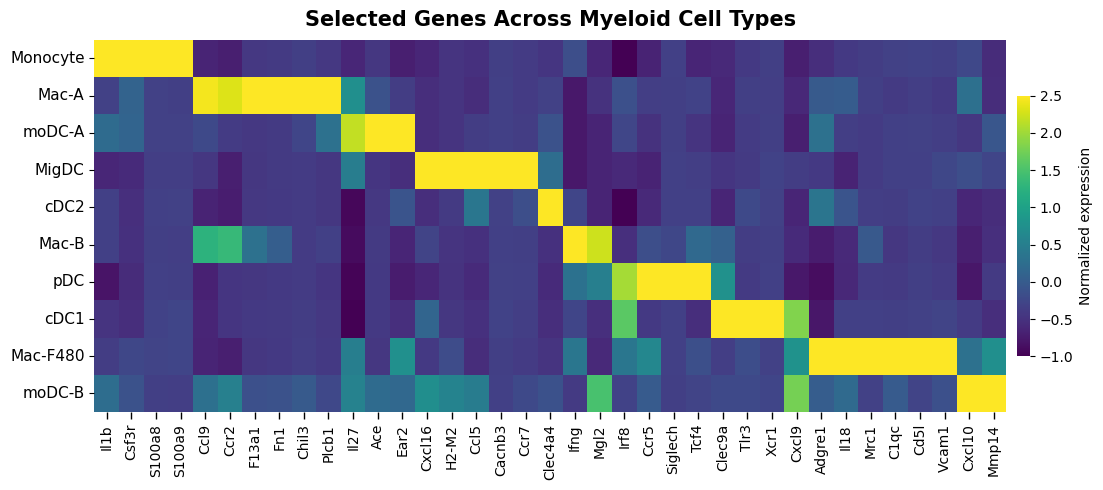


✅ Heatmap complete!
   Cell types: 10
   Genes: 37
   Missing genes: 0 - none


In [ ]:
print("Creating heatmap with correct expression data and ordering...")

# Define display order for cell types
cell_type_order = [
    'Monocyte',
    'Mac-A',
    'moDC-A',
    'MigDC',
    'cDC2',
    'Mac-B',
    'pDC',
    'cDC1',
    'Mac-F480',
    'moDC-B'
]

# Reorder rows and columns
expr_df_ordered = expr_df_new_norm.reindex(index=cell_type_order, columns=genes_present)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

# Plot heatmap
sns.heatmap(
    expr_df_ordered,
    cmap='viridis',
    vmin=-1,
    vmax=2.5,
    cbar_kws={
        'label': 'Normalized expression',
        'shrink': 0.7,
        'pad': 0.01
    },
    linewidths=0.001,
    linecolor='white',
    square=False,
    ax=ax,
    yticklabels=True,
    xticklabels=True
)

ax.set_title('Selected Genes Across Myeloid Cell Types', 
             fontsize=15, fontweight='bold', pad=10)

plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)

# Add tick marks on x-axis
ax.tick_params(axis='x', which='major', length=5, width=1, direction='out', bottom=True)

plt.tight_layout()
plt.savefig('myeloid_gene_expression_heatmap_final.png', dpi=300, bbox_inches='tight')
plt.savefig('myeloid_gene_expression_heatmap_final.pdf', bbox_inches='tight')
print("📊 Saved: myeloid_gene_expression_heatmap_final.png/pdf")
plt.show()

print(f"\n✅ Heatmap complete!")
print(f"   Cell types: {len(cell_type_order)}")
print(f"   Genes: {len(genes_present)}")
print(f"   Missing genes: {len(genes_missing)} - {genes_missing if genes_missing else 'none'}")

In [ ]:
# Extract expression data - INFECTED ONLY
print("Extracting expression data - INFECTED (3wk timepoint)\n")

# Filter for infected cells
adata_infected = adata_sc_new[adata_sc_new.obs['timepoint'] == '3wk'].copy()
print(f"Infected cells: {adata_infected.shape[0]}")

# Myeloid types
myeloid_types_current = [
    'Myeloid_monocyte', 'Myeloid_Macrophage', 'Myeloid_moDC', 'Myeloid_migratory',
    'Myeloid_DC2', 'Myeloid_Macrophage-CXCL9/10', 'Myeloid_pDC', 'Myeloid_cDC1',
    'Myeloid_marginalzone', 'Myeloid_moDC-CXCL9/10'
]

name_mapping_for_display = {
    'Myeloid_monocyte': 'Monocyte', 'Myeloid_Macrophage': 'Mac-A',
    'Myeloid_moDC': 'moDC-A', 'Myeloid_migratory': 'MigDC', 'Myeloid_DC2': 'cDC2',
    'Myeloid_Macrophage-CXCL9/10': 'Mac-B', 'Myeloid_pDC': 'pDC', 'Myeloid_cDC1': 'cDC1',
    'Myeloid_marginalzone': 'Mac-F480', 'Myeloid_moDC-CXCL9/10': 'moDC-B'
}

adata_myeloid_new = adata_infected[adata_infected.obs['celltypes_redo'].isin(myeloid_types_current)].copy()
print(f"Myeloid cells: {adata_myeloid_new.shape[0]}")

gene_order = [
    'Il1b', 'Csf3r', 'S100a8', 'S100a9', 'Ccl9', 'Ccr2',
    'F13a1', 'Fn1', 'Chil3', 'Plcb1', 'Il27', 'Ace', 'Ear2', 'Cxcl16',
    'H2-M2', 'Ccl5', 'Cacnb3', 'Ccr7', 'Clec4a4', 'Ifng', 'Mgl2', 'Irf8', 'Ccr5', 'Siglech', 'Tcf4',
    'Clec9a', 'Tlr3', 'Xcr1', 'Cxcl9', 'Adgre1', 'Il18',
    'Mrc1', 'C1qc', 'Cd5l', 'Vcam1', 'Cxcl10', 'Mmp14'
]

genes_present = [g for g in gene_order if g in adata_myeloid_new.var_names]
genes_missing = [g for g in gene_order if g not in adata_myeloid_new.var_names]
print(f"\nGenes present: {len(genes_present)}/{len(gene_order)}")

adata_subset_new = adata_myeloid_new[:, genes_present].copy()

# Calculate mean expression per cell type
expr_matrix = []
cell_type_labels = []

for cell_type in myeloid_types_current:
    cells_mask = adata_subset_new.obs['celltypes_redo'] == cell_type
    cells = adata_subset_new[cells_mask]
    
    if cells.shape[0] > 0:
        X = cells.X.toarray() if hasattr(cells.X, 'toarray') else cells.X
        mean_expr = X.mean(axis=0)
        expr_matrix.append(mean_expr)
        cell_type_labels.append(name_mapping_for_display[cell_type])

expr_df_new = pd.DataFrame(expr_matrix, index=cell_type_labels, columns=genes_present)

from scipy.stats import zscore
expr_df_new_norm = expr_df_new.apply(zscore, axis=0)

print(f"Expression matrix: {expr_df_new_norm.shape}")
print("✅ Data ready!")

Extracting expression data - INFECTED (3wk timepoint)

Infected cells: 28692
Myeloid cells: 7943

Genes present: 37/37
Expression matrix: (10, 37)
✅ Data ready!


📊 Saved: myeloid_gene_expression_heatmap_INFECTED.png/pdf


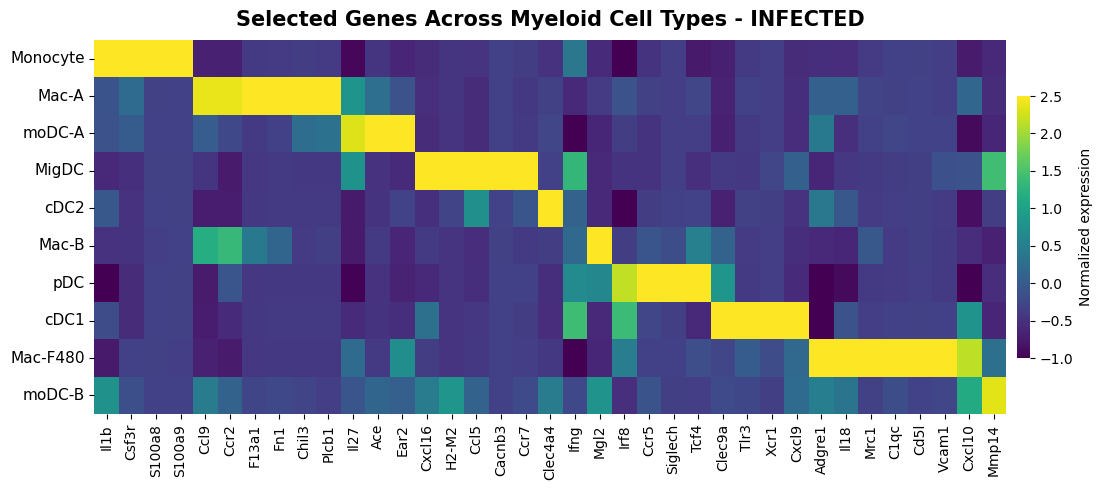

In [ ]:
# Create heatmap - INFECTED
cell_type_order = ['Monocyte', 'Mac-A', 'moDC-A', 'MigDC', 'cDC2', 
                   'Mac-B', 'pDC', 'cDC1', 'Mac-F480', 'moDC-B']

expr_df_ordered = expr_df_new_norm.reindex(index=cell_type_order, columns=genes_present)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(expr_df_ordered, cmap='viridis', vmin=-1, vmax=2.5,
            cbar_kws={'label': 'Normalized expression', 'shrink': 0.7, 'pad': 0.01},
            linewidths=0.001, linecolor='white', square=False, ax=ax,
            yticklabels=True, xticklabels=True)

ax.set_title('Selected Genes Across Myeloid Cell Types - INFECTED', 
             fontsize=15, fontweight='bold', pad=10)

plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

plt.savefig('myeloid_gene_expression_heatmap_INFECTED.png', dpi=300, bbox_inches='tight')
plt.savefig('myeloid_gene_expression_heatmap_INFECTED.pdf', bbox_inches='tight')
print("📊 Saved: myeloid_gene_expression_heatmap_INFECTED.png/pdf")
plt.show()

In [ ]:
# Extract expression data - UNINFECTED ONLY
print("Extracting expression data - UNINFECTED (02k timepoint)\n")

# Filter for uninfected cells
adata_uninfected = adata_sc_new[adata_sc_new.obs['timepoint'] == '0wk'].copy()
print(f"Uninfected cells: {adata_uninfected.shape[0]}")

# Myeloid types
myeloid_types_current = [
    'Myeloid_monocyte', 'Myeloid_Macrophage', 'Myeloid_moDC', 'Myeloid_migratory',
    'Myeloid_DC2', 'Myeloid_Macrophage-CXCL9/10', 'Myeloid_pDC', 'Myeloid_cDC1',
    'Myeloid_marginalzone', 'Myeloid_moDC-CXCL9/10'
]

name_mapping_for_display = {
    'Myeloid_monocyte': 'Monocyte', 'Myeloid_Macrophage': 'Mac-A',
    'Myeloid_moDC': 'moDC-A', 'Myeloid_migratory': 'MigDC', 'Myeloid_DC2': 'cDC2',
    'Myeloid_Macrophage-CXCL9/10': 'Mac-B', 'Myeloid_pDC': 'pDC', 'Myeloid_cDC1': 'cDC1',
    'Myeloid_marginalzone': 'Mac-F480', 'Myeloid_moDC-CXCL9/10': 'moDC-B'
}

adata_myeloid_new = adata_uninfected[adata_uninfected.obs['celltypes_redo'].isin(myeloid_types_current)].copy()
print(f"Myeloid cells: {adata_myeloid_new.shape[0]}")

gene_order = [
    'Il1b', 'Csf3r', 'S100a8', 'S100a9', 'Ccl9', 'Ccr2',
    'F13a1', 'Fn1', 'Chil3', 'Plcb1', 'Il27', 'Ace', 'Ear2', 'Cxcl16',
    'H2-M2', 'Ccl5', 'Cacnb3', 'Ccr7', 'Clec4a4', 'Ifng', 'Mgl2', 'Irf8', 'Ccr5', 'Siglech', 'Tcf4',
    'Clec9a', 'Tlr3', 'Xcr1', 'Cxcl9', 'Adgre1', 'Il18',
    'Mrc1', 'C1qc', 'Cd5l', 'Vcam1', 'Cxcl10', 'Mmp14'
]

genes_present = [g for g in gene_order if g in adata_myeloid_new.var_names]
genes_missing = [g for g in gene_order if g not in adata_myeloid_new.var_names]
print(f"\nGenes present: {len(genes_present)}/{len(gene_order)}")

adata_subset_new = adata_myeloid_new[:, genes_present].copy()

# Calculate mean expression per cell type
expr_matrix = []
cell_type_labels = []

for cell_type in myeloid_types_current:
    cells_mask = adata_subset_new.obs['celltypes_redo'] == cell_type
    cells = adata_subset_new[cells_mask]
    
    if cells.shape[0] > 0:
        X = cells.X.toarray() if hasattr(cells.X, 'toarray') else cells.X
        mean_expr = X.mean(axis=0)
        expr_matrix.append(mean_expr)
        cell_type_labels.append(name_mapping_for_display[cell_type])

expr_df_new = pd.DataFrame(expr_matrix, index=cell_type_labels, columns=genes_present)

from scipy.stats import zscore
expr_df_new_norm = expr_df_new.apply(zscore, axis=0)

print(f"Expression matrix: {expr_df_new_norm.shape}")
print("✅ Data ready!")

Extracting expression data - UNINFECTED (02k timepoint)

Uninfected cells: 31994
Myeloid cells: 5225

Genes present: 37/37
Expression matrix: (10, 37)
✅ Data ready!


📊 Saved: myeloid_gene_expression_heatmap_UNINFECTED.png/pdf


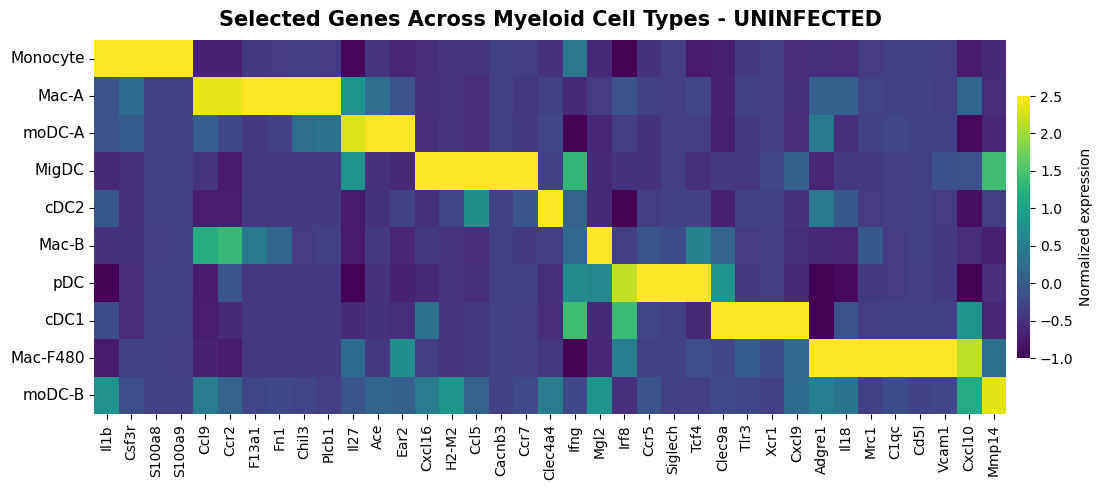

In [ ]:
# Create heatmap - UNINFECTED
cell_type_order = ['Monocyte', 'Mac-A', 'moDC-A', 'MigDC', 'cDC2', 
                   'Mac-B', 'pDC', 'cDC1', 'Mac-F480', 'moDC-B']

expr_df_ordered = expr_df_new_norm.reindex(index=cell_type_order, columns=genes_present)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(expr_df_ordered, cmap='viridis', vmin=-1, vmax=2.5,
            cbar_kws={'label': 'Normalized expression', 'shrink': 0.7, 'pad': 0.01},
            linewidths=0.001, linecolor='white', square=False, ax=ax,
            yticklabels=True, xticklabels=True)

ax.set_title('Selected Genes Across Myeloid Cell Types - UNINFECTED', 
             fontsize=15, fontweight='bold', pad=10)

plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()

plt.savefig('myeloid_gene_expression_heatmap_UNINFECTED.png', dpi=300, bbox_inches='tight')
plt.savefig('myeloid_gene_expression_heatmap_UNINFECTED.pdf', bbox_inches='tight')
print("📊 Saved: myeloid_gene_expression_heatmap_UNINFECTED.png/pdf")
plt.show()

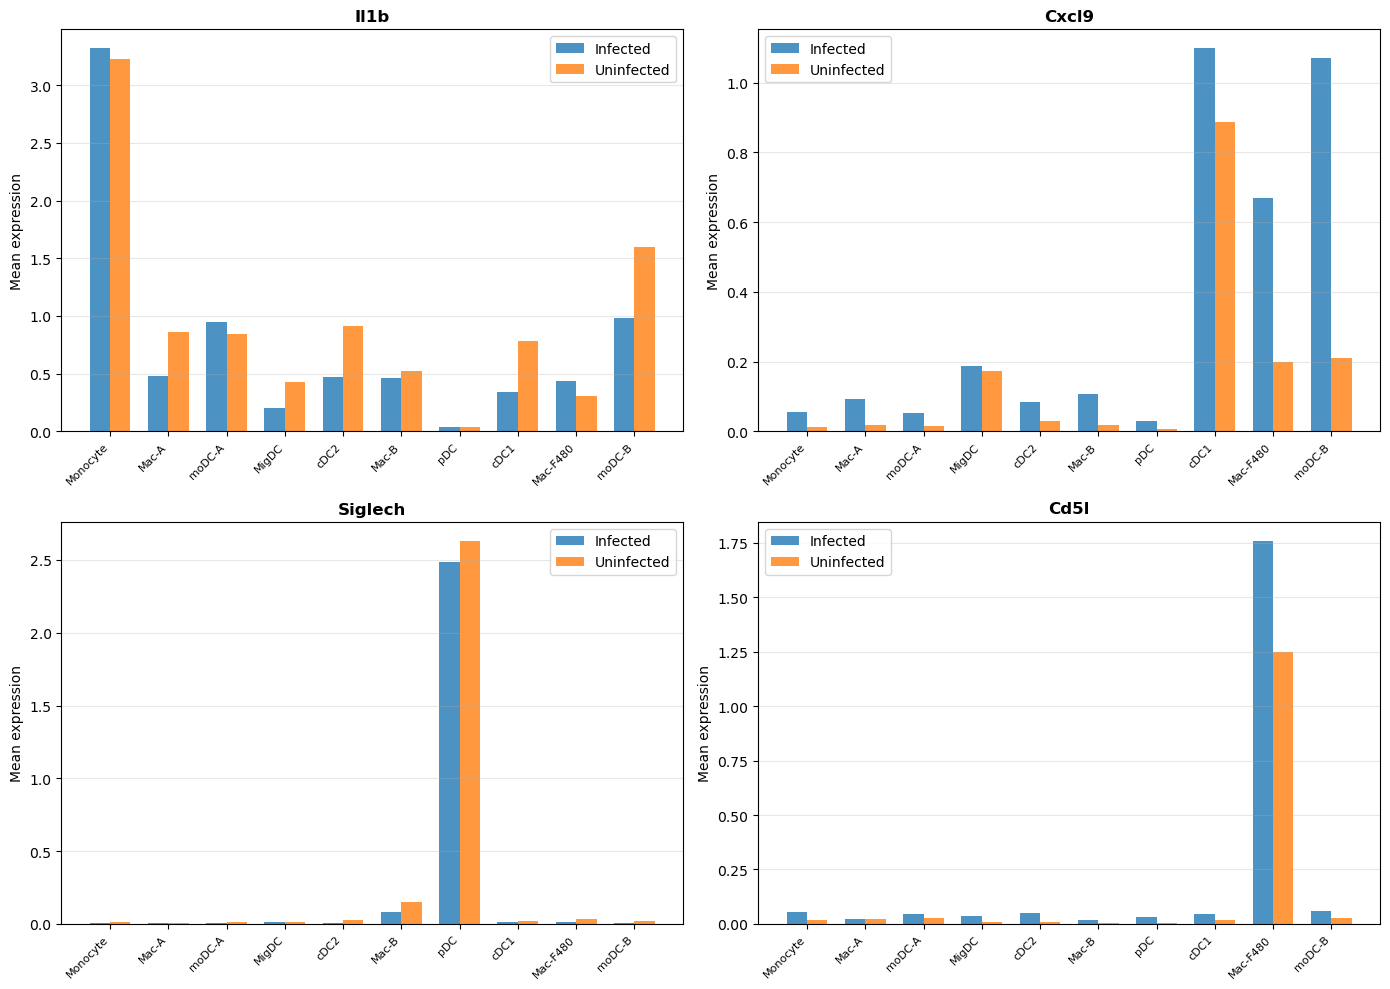

If the bars look similar = cell type patterns are similar between conditions
If bars are different heights = infection changes absolute expression


In [ ]:
# Compare a few example genes to see what's happening
test_genes = ['Il1b', 'Cxcl9', 'Siglech', 'Cd5l']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, gene in enumerate(test_genes):
    ax = axes[idx]
    
    inf_expr = expr_df_inf[gene].reindex(cell_type_order)
    uninf_expr = expr_df_uninf[gene].reindex(cell_type_order)
    
    x = np.arange(len(cell_type_order))
    width = 0.35
    
    ax.bar(x - width/2, inf_expr, width, label='Infected', alpha=0.8)
    ax.bar(x + width/2, uninf_expr, width, label='Uninfected', alpha=0.8)
    ax.set_title(f'{gene}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cell_type_order, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean expression')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("If the bars look similar = cell type patterns are similar between conditions")
print("If bars are different heights = infection changes absolute expression")

In [4]:
import scanpy as sc
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from collections import OrderedDict
from scipy.stats import zscore

warnings.filterwarnings('ignore')

adata_sc_new = sc.read_h5ad("/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad")
adata_sc_new_inf = adata_sc_new[adata_sc_new.obs['timepoint'] == '3wk'].copy()

In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import zscore
import warnings

warnings.filterwarnings('ignore')

# Load the single-cell data
adata_sc_new = sc.read_h5ad("/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad")

print("Setting up CD8 T cell heatmap (excluding gamma-delta and NKT)...\n")

# CD8 cell types (excluding gamma-delta and NKT)
cd8_types_current = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active',
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
    'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating'
]

# Display names (keeping same format)
cd8_name_mapping = {
    'CD8-Tcell_naive': 'CD8-Tcell_naive',
    'CD8-Tcell_early-active': 'CD8-Tcell_early-active',
    'CD8-Tcell_effector': 'CD8-Tcell_effector',
    'CD8-Tcell_late-active': 'CD8-Tcell_late-active',
    'CD8-Tcell_terminal': 'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating': 'CD8-Tcell_proliferating'
}

# Gene list from reference (removing duplicates)
cd8_genes = [
    'Tox', 'Hdac9', 'Myb', 'Sox4', 'Id3', 'Ift80', 'Slamf6', 'Itgae', 'Slc6a19', 'Bach2', 'Foxp1',
    'Sell', 'Aff3', 'Tcf7', 'St8sia1', 'Il6ra', 'Ccr7', 'Dapl1', 'Actn1', 'Lef1', 'Ifi213', 'Il27ra', 'Satb1',
    'Ccr9', 'Inpp4b', 'Ikzf2', 'Ctla2a', 'Ifngas1', 'Sidt1', 'Kbtbd11', 'Bcl2', 'Ms4a4c', 'Eomes', 'Pde2a', 'Ly6c2', 'Ifng',
    'Gzmb', 'Gzmk', 'Lgals1', 'S100a10', 'Gzma', 'Cx3cr1', 'Zeb2', 'Kcnj8', 'Prf1', 'Ccr5', 'Tbx21', 'Ccl5', 'Il18r1', 'Itgb1', 'Nkg7', 
    'Ahnak', 'Il18rap', 'Cd5', 'Ly6a', 'Txn1', 'Stmn1', 'Mki67', 'Pclaf', 'Cxcr5', 'Klrg1', 'Cd44'
]

# Remove duplicates while preserving order
cd8_genes_unique = list(dict.fromkeys(cd8_genes))

print(f"CD8 cell types: {len(cd8_types_current)}")
print(f"Genes: {len(cd8_genes_unique)}")

# Filter for CD8 cells
adata_cd8 = adata_sc_new[adata_sc_new.obs['celltypes_redo'].isin(cd8_types_current)].copy()
print(f"\nCD8 cells: {adata_cd8.shape[0]}")

# Check which genes are present
cd8_genes_present = [g for g in cd8_genes_unique if g in adata_cd8.var_names]
cd8_genes_missing = [g for g in cd8_genes_unique if g not in adata_cd8.var_names]

print(f"\nGenes present: {len(cd8_genes_present)}/{len(cd8_genes_unique)}")
if cd8_genes_missing:
    print(f"Missing genes ({len(cd8_genes_missing)}): {cd8_genes_missing}")

# Subset to genes
adata_cd8_subset = adata_cd8[:, cd8_genes_present].copy()

# Calculate mean expression
print("\nCalculating mean expression...")
expr_matrix_cd8 = []
cell_type_labels_cd8 = []

for cell_type in cd8_types_current:
    cells_mask = adata_cd8_subset.obs['celltypes_redo'] == cell_type
    cells = adata_cd8_subset[cells_mask]
    
    if cells.shape[0] > 0:
        if hasattr(cells.X, 'toarray'):
            X = cells.X.toarray()
        else:
            X = cells.X
        
        mean_expr = X.mean(axis=0)
        expr_matrix_cd8.append(mean_expr)
        cell_type_labels_cd8.append(cd8_name_mapping[cell_type])

# Create dataframe
expr_df_cd8 = pd.DataFrame(
    expr_matrix_cd8,
    index=cell_type_labels_cd8,
    columns=cd8_genes_present
)

# Z-score normalize
expr_df_cd8_norm = expr_df_cd8.apply(zscore, axis=0)

print(f"\nExpression matrix: {expr_df_cd8_norm.shape}")
print(f"Cell types: {expr_df_cd8_norm.index.tolist()}")
print("\n✅ CD8 data ready!")

Setting up CD8 T cell heatmap (excluding gamma-delta and NKT)...

CD8 cell types: 6
Genes: 62

CD8 cells: 9537

Genes present: 62/62

Calculating mean expression...

Expression matrix: (6, 62)
Cell types: ['CD8-Tcell_naive', 'CD8-Tcell_early-active', 'CD8-Tcell_effector', 'CD8-Tcell_late-active', 'CD8-Tcell_terminal', 'CD8-Tcell_proliferating']

✅ CD8 data ready!


Setting up CD8 T cell heatmap (INFECTED ONLY)...

CD8 cell types: 5
Genes: 35

Filtering for infected cells (3wk timepoint)...
Total infected cells: 28692
Infected CD8 cells: 6225

Cells per population (infected only):
  CD8-Tcell_naive: 3168
  CD8-Tcell_early-active: 926
  CD8-Tcell_proliferating: 543
  CD8-Tcell_late-active: 449
  CD8-Tcell_effector: 1139

Genes present: 34/35
Missing genes (1): ['Il12']

Calculating mean expression...

Expression matrix: (5, 34)
Cell types: ['CD8-Tcell_naive', 'CD8-Tcell_early-active', 'CD8-Tcell_proliferating', 'CD8-Tcell_late-active', 'CD8-Tcell_effector']

✅ CD8 data ready!

Creating CD8 T cell heatmap (ordered by peak expression)...

CD8-Tcell_naive: 8 genes
CD8-Tcell_early-active: 4 genes
CD8-Tcell_proliferating: 9 genes
CD8-Tcell_late-active: 4 genes
CD8-Tcell_effector: 9 genes
Z-score range: -1.88 to 2.00

📊 Saved: cd8_gene_expression_heatmap_infected_ordered.png/pdf


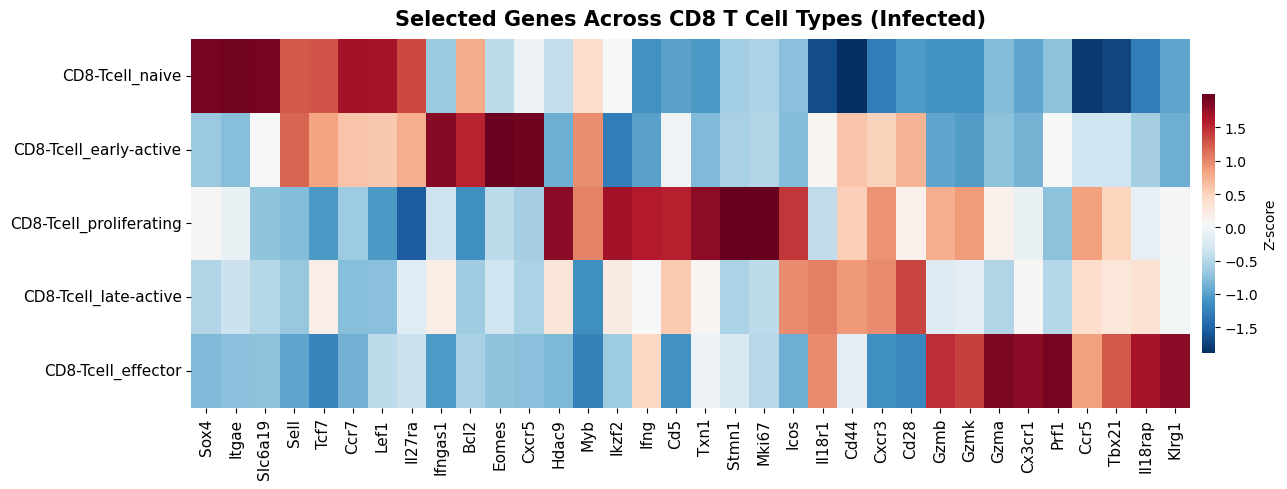


✅ CD8 Heatmap (infected only, ordered by peak expression) complete!


In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings

warnings.filterwarnings('ignore')

# Load the single-cell data
adata_sc_new = sc.read_h5ad("/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad")

print("Setting up CD8 T cell heatmap (INFECTED ONLY)...\n")

# CD8 cell types (excluding gamma-delta and NKT)
cd8_types_current = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active',
    'CD8-Tcell_proliferating',
    'CD8-Tcell_late-active',
    'CD8-Tcell_effector'

]

# Gene list from reference (removing duplicates)
cd8_genes = [
    'Hdac9', 'Myb', 'Sox4', 'Itgae', 'Slc6a19',
    'Sell', 'Tcf7', 'Ccr7', 'Lef1', 'Il27ra', 'Ikzf2',  'Ifngas1', 'Bcl2', 'Eomes', 'Ifng',
    'Gzmb', 'Gzmk', 'Gzma', 'Cx3cr1', 'Prf1', 'Ccr5', 'Tbx21', 'Il18r1', 
    'Il18rap', 'Cd5', 'Txn1', 'Stmn1', 'Mki67', 'Cxcr5', 'Klrg1', 'Cd44', 'Tcf7', 'Cxcr3', 'Il12', 'Cd28', 'Icos'
]

# Remove duplicates while preserving order
cd8_genes_unique = list(dict.fromkeys(cd8_genes))

print(f"CD8 cell types: {len(cd8_types_current)}")
print(f"Genes: {len(cd8_genes_unique)}")

# FILTER FOR INFECTED CELLS ONLY (3wk timepoint)
print("\nFiltering for infected cells (3wk timepoint)...")
adata_infected = adata_sc_new[adata_sc_new.obs['timepoint'] == '3wk'].copy()
print(f"Total infected cells: {adata_infected.shape[0]}")

# Filter for CD8 cells - INFECTED ONLY
adata_cd8_infected = adata_infected[adata_infected.obs['celltypes_redo'].isin(cd8_types_current)].copy()
print(f"Infected CD8 cells: {adata_cd8_infected.shape[0]}")

print("\nCells per population (infected only):")
for ct in cd8_types_current:
    n_cells = (adata_cd8_infected.obs['celltypes_redo'] == ct).sum()
    print(f"  {ct}: {n_cells}")

# Check which genes are present
cd8_genes_present = [g for g in cd8_genes_unique if g in adata_cd8_infected.var_names]
cd8_genes_missing = [g for g in cd8_genes_unique if g not in adata_cd8_infected.var_names]

print(f"\nGenes present: {len(cd8_genes_present)}/{len(cd8_genes_unique)}")
if cd8_genes_missing:
    print(f"Missing genes ({len(cd8_genes_missing)}): {cd8_genes_missing}")

# Subset to genes
adata_cd8_subset = adata_cd8_infected[:, cd8_genes_present].copy()

# Calculate mean expression
print("\nCalculating mean expression...")
expr_matrix_cd8 = []
cell_type_labels_cd8 = []

for cell_type in cd8_types_current:
    cells_mask = adata_cd8_subset.obs['celltypes_redo'] == cell_type
    cells = adata_cd8_subset[cells_mask]
    
    if cells.shape[0] > 0:
        if hasattr(cells.X, 'toarray'):
            X = cells.X.toarray()
        else:
            X = cells.X
        
        mean_expr = X.mean(axis=0)
        expr_matrix_cd8.append(mean_expr)
        cell_type_labels_cd8.append(cell_type)

# Create dataframe
expr_df_cd8 = pd.DataFrame(
    expr_matrix_cd8,
    index=cell_type_labels_cd8,
    columns=cd8_genes_present
)

# Z-score normalize
expr_df_cd8_norm = expr_df_cd8.apply(zscore, axis=0)
expr_df_cd8_norm = expr_df_cd8_norm.fillna(0)

print(f"\nExpression matrix: {expr_df_cd8_norm.shape}")
print(f"Cell types: {expr_df_cd8_norm.index.tolist()}")
print("\n✅ CD8 data ready!")

# Now create the heatmap
print("\nCreating CD8 T cell heatmap (ordered by peak expression)...\n")

# For each gene, find which cell type has highest expression
gene_to_peak_celltype = {}
for gene in expr_df_cd8_norm.columns:
    peak_celltype = expr_df_cd8_norm[gene].idxmax()
    gene_to_peak_celltype[gene] = peak_celltype

# Group genes by their peak cell type (in order of cell type progression)
genes_by_celltype = {ct: [] for ct in cd8_types_current}
for gene, peak_ct in gene_to_peak_celltype.items():
    genes_by_celltype[peak_ct].append(gene)

# Concatenate genes in order of cell types
ordered_genes = []
for ct in cd8_types_current:
    ordered_genes.extend(genes_by_celltype[ct])
    print(f"{ct}: {len(genes_by_celltype[ct])} genes")

# Reorder columns by peak expression
expr_df_cd8_ordered = expr_df_cd8_norm[ordered_genes]

# Calculate actual z-score range (don't cut it off prematurely)
vmin = expr_df_cd8_ordered.min().min()
vmax = expr_df_cd8_ordered.max().max()

print(f"Z-score range: {vmin:.2f} to {vmax:.2f}")

# Create figure (NO BRACKETS)
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    expr_df_cd8_ordered,
    cmap='RdBu_r',
    vmin=vmin,  # Use actual data range
    vmax=vmax,  # Use actual data range
    cbar_kws={
        'label': 'Z-score',
        'shrink': 0.7,
        'pad': 0.01
    },
    linewidths=0,
    linecolor='white',
    square=False,
    ax=ax,
    yticklabels=True,
    xticklabels=True
)

ax.set_title('Selected Genes Across CD8 T Cell Types (Infected)', 
             fontsize=15, fontweight='bold', pad=10)

plt.xticks(rotation=90, ha='center', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('cd8_gene_expression_heatmap_infected_ordered.png', dpi=300, bbox_inches='tight')
plt.savefig('cd8_gene_expression_heatmap_infected_ordered.pdf', bbox_inches='tight')
print("\n📊 Saved: cd8_gene_expression_heatmap_infected_ordered.png/pdf")
plt.show()

print(f"\n✅ CD8 Heatmap (infected only, ordered by peak expression) complete!")

In [5]:
print("Setting up coarse cell type cluster heatmap...\n")

# Gene list from reference (left to right)
coarse_genes = [
    'Klf3l1c', 'Klre1', 'Cd4', 'Cd8a', 'Cd3b1', 'Tbx2', 'Cd3d', 'Cd3e',
    'Themis', 'Cd79b', 'Cd19', 'Cd79a', 'Gctm', 'Prdx2', 'Col1a1', 'Col1a2',
    'Cdh5', 'Stab2', 'Cpa3', 'Cyp11a1', 'Camp', 'Ngp', 'S100a8', 'S100a9',
    'Csf3r', 'Csf1r', 'Cst3'
]

# Coarse cell types (from image, top to bottom)
coarse_cell_types = [
    'NK',
    'CD4-Tcell',
    'CD8-Tcell',
    'Bcell',
    'Hematopoietic',
    'Endothelial',
    'Fibroblast',
    'Mast-Cell',
    'Myeloid',
    'Neutrophil'
]

print(f"Coarse cell types: {len(coarse_cell_types)}")
print(f"Genes: {len(coarse_genes)}")

# Check if coarse_redo column exists
if 'coarse_redo' not in adata_sc_new.obs.columns:
    print("\nERROR: 'coarse_redo' column not found!")
    print(f"Available columns with 'coarse': {[c for c in adata_sc_new.obs.columns if 'coarse' in c.lower()]}")
else:
    print(f"\nUnique values in coarse_redo: {adata_sc_new.obs['coarse_redo'].unique()}")
    
    # Filter for coarse cell types
    adata_coarse = adata_sc_new[adata_sc_new.obs['coarse_redo'].isin(coarse_cell_types)].copy()
    print(f"\nCoarse cells: {adata_coarse.shape[0]}")
    
    # Check which genes are present
    coarse_genes_present = [g for g in coarse_genes if g in adata_coarse.var_names]
    coarse_genes_missing = [g for g in coarse_genes if g not in adata_coarse.var_names]
    
    print(f"\nGenes present: {len(coarse_genes_present)}/{len(coarse_genes)}")
    if coarse_genes_missing:
        print(f"Missing genes: {coarse_genes_missing}")
    
    # Subset to genes
    adata_coarse_subset = adata_coarse[:, coarse_genes_present].copy()
    
    # Calculate mean expression
    print("\nCalculating mean expression...")
    expr_matrix_coarse = []
    cell_type_labels_coarse = []
    
    for cell_type in coarse_cell_types:
        cells_mask = adata_coarse_subset.obs['coarse_redo'] == cell_type
        cells = adata_coarse_subset[cells_mask]
        
        if cells.shape[0] > 0:
            if hasattr(cells.X, 'toarray'):
                X = cells.X.toarray()
            else:
                X = cells.X
            
            mean_expr = X.mean(axis=0)
            expr_matrix_coarse.append(mean_expr)
            cell_type_labels_coarse.append(cell_type)
    
    # Create dataframe
    expr_df_coarse = pd.DataFrame(
        expr_matrix_coarse,
        index=cell_type_labels_coarse,
        columns=coarse_genes_present
    )
    
    # Z-score normalize
    expr_df_coarse_norm = expr_df_coarse.apply(zscore, axis=0)
    
    print(f"\nExpression matrix: {expr_df_coarse_norm.shape}")
    print(f"Cell types: {expr_df_coarse_norm.index.tolist()}")
    print("\n✅ Coarse cluster data ready!")

Setting up coarse cell type cluster heatmap...

Coarse cell types: 10
Genes: 27

Unique values in coarse_redo: ['Hematopoietic', 'Myeloid', 'CD8-Tcell', 'CD4-Tcell', 'NK', 'Neutrophil', 'Bcell', 'Mast-Cell', 'Endothelial', 'Fibroblast']
Categories (10, object): ['Bcell', 'CD4-Tcell', 'CD8-Tcell', 'Endothelial', ..., 'Mast-Cell', 'Myeloid', 'NK', 'Neutrophil']

Coarse cells: 60686

Genes present: 24/27
Missing genes: ['Klf3l1c', 'Cd3b1', 'Gctm']

Calculating mean expression...

Expression matrix: (10, 24)
Cell types: ['NK', 'CD4-Tcell', 'CD8-Tcell', 'Bcell', 'Hematopoietic', 'Endothelial', 'Fibroblast', 'Mast-Cell', 'Myeloid', 'Neutrophil']

✅ Coarse cluster data ready!


In [6]:
print("Setting up coarse cell type cluster heatmap with CORRECT genes...\n")

# CORRECTED gene list from reference (left to right)
coarse_genes = [
    'Klrb1c', 'Klre1', 'Cd4', 'Cd8a', 'Cd8b1', 'Trbc2', 'Cd3d', 'Cd3e',
    'Themis', 'Cd79b', 'Cd19', 'Cd79a', 'Gclm', 'Prdx2', 'Cdh5', 'Stab2', 'Col1a1', 'Col1a2',
    'Cpa3', 'Cyp11a1', 'Csf3r', 'Csf1r', 'Cst3','Camp', 'Ngp', 'S100a8', 'S100a9'
]

# Coarse cell types (from image, top to bottom)
coarse_cell_types = [
    'NK',
    'CD4-Tcell',
    'CD8-Tcell',
    'Bcell',
    'Hematopoietic',
    'Endothelial',
    'Fibroblast',
    'Mast-Cell',
    'Myeloid',
    'Neutrophil'
]

print(f"Coarse cell types: {len(coarse_cell_types)}")
print(f"Genes: {len(coarse_genes)}")

# Filter for coarse cell types
adata_coarse = adata_sc_new[adata_sc_new.obs['coarse_redo'].isin(coarse_cell_types)].copy()
print(f"\nCoarse cells: {adata_coarse.shape[0]}")

# Check which genes are present
coarse_genes_present = [g for g in coarse_genes if g in adata_coarse.var_names]
coarse_genes_missing = [g for g in coarse_genes if g not in adata_coarse.var_names]

print(f"\nGenes present: {len(coarse_genes_present)}/{len(coarse_genes)}")
if coarse_genes_missing:
    print(f"Missing genes: {coarse_genes_missing}")

# Subset to genes
adata_coarse_subset = adata_coarse[:, coarse_genes_present].copy()

# Calculate mean expression
print("\nCalculating mean expression...")
expr_matrix_coarse = []
cell_type_labels_coarse = []

for cell_type in coarse_cell_types:
    cells_mask = adata_coarse_subset.obs['coarse_redo'] == cell_type
    cells = adata_coarse_subset[cells_mask]
    
    if cells.shape[0] > 0:
        if hasattr(cells.X, 'toarray'):
            X = cells.X.toarray()
        else:
            X = cells.X
        
        mean_expr = X.mean(axis=0)
        expr_matrix_coarse.append(mean_expr)
        cell_type_labels_coarse.append(cell_type)

# Create dataframe
expr_df_coarse = pd.DataFrame(
    expr_matrix_coarse,
    index=cell_type_labels_coarse,
    columns=coarse_genes_present
)

# Z-score normalize
expr_df_coarse_norm = expr_df_coarse.apply(zscore, axis=0)

print(f"\nExpression matrix: {expr_df_coarse_norm.shape}")
print(f"Cell types: {expr_df_coarse_norm.index.tolist()}")
print("\n✅ Coarse cluster data ready with corrected genes!")

Setting up coarse cell type cluster heatmap with CORRECT genes...

Coarse cell types: 10
Genes: 27

Coarse cells: 60686

Genes present: 27/27

Calculating mean expression...

Expression matrix: (10, 27)
Cell types: ['NK', 'CD4-Tcell', 'CD8-Tcell', 'Bcell', 'Hematopoietic', 'Endothelial', 'Fibroblast', 'Mast-Cell', 'Myeloid', 'Neutrophil']

✅ Coarse cluster data ready with corrected genes!


Creating coarse cell type cluster heatmap...
Z-score range: -0.96 to 3.00


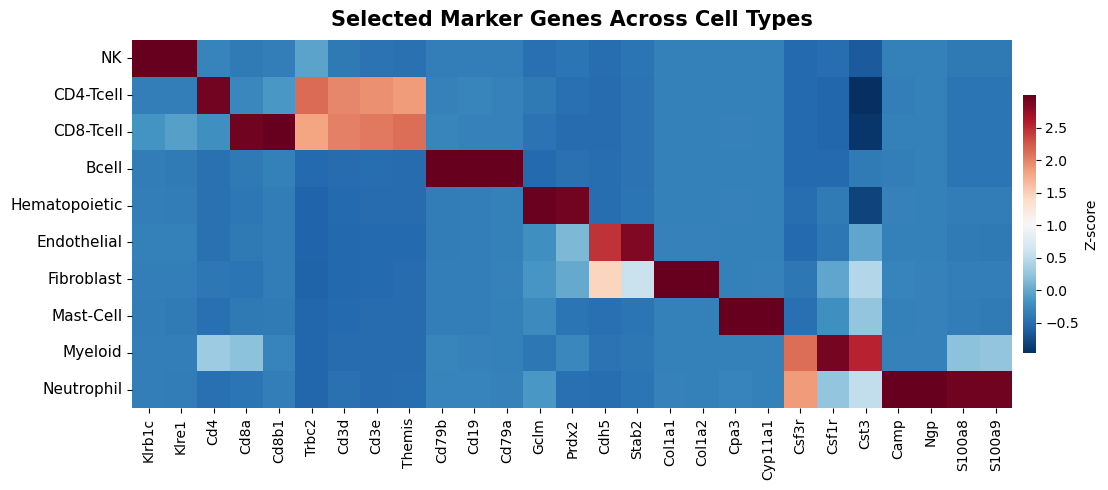


✅ Coarse cluster heatmap complete!
   Cell types: 10
   Genes: 27
   Missing genes: 0 - none


In [7]:
print("Creating coarse cell type cluster heatmap...")

# Reorder rows and columns
expr_df_coarse_ordered = expr_df_coarse_norm.reindex(index=cell_type_labels_coarse, columns=coarse_genes_present)

# Calculate actual z-score range
vmin = expr_df_coarse_ordered.min().min()
vmax = expr_df_coarse_ordered.max().max()

print(f"Z-score range: {vmin:.2f} to {vmax:.2f}")

# Create figure (same dimensions as previous plots)
fig, ax = plt.subplots(figsize=(12, 5))

# Plot heatmap
sns.heatmap(
    expr_df_coarse_ordered,
    cmap='RdBu_r',
    vmin=vmin,  # Use actual data range
    vmax=vmax,  # Use actual data range
    cbar_kws={
        'label': 'Z-score',
        'shrink': 0.7,
        'pad': 0.01
    },
    linewidths=0.001,
    linecolor='white',
    square=False,
    ax=ax,
    yticklabels=True,
    xticklabels=True
)

ax.set_title('Selected Marker Genes Across Cell Types', 
             fontsize=15, fontweight='bold', pad=10)

plt.xticks(rotation=90, ha='center', fontsize=10)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()

plt.show()

print(f"\n✅ Coarse cluster heatmap complete!")
print(f"   Cell types: {len(cell_type_labels_coarse)}")
print(f"   Genes: {len(coarse_genes_present)}")
print(f"   Missing genes: {len(coarse_genes_missing)} - {coarse_genes_missing if coarse_genes_missing else 'none'}")

In [ ]:
print("=" * 80)
print("DIFFERENTIAL EXPRESSION - ALL CD8 T CELLS (INFECTED ONLY)")
print("Comparing each CD8 population vs all others")
print("=" * 80)
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load data
sc_data_path = '/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad'
adata_full = sc.read_h5ad(sc_data_path)

# Get all CD8 populations
all_celltypes = adata_full.obs['celltypes_redo'].unique()
cd8_populations = sorted([ct for ct in all_celltypes if 'CD8' in ct])

print(f"\nCD8 populations: {cd8_populations}")

# Filter for infected (3wk) CD8 cells
adata_cd8_infected = adata_full[
    (adata_full.obs['celltypes_redo'].isin(cd8_populations)) & 
    (adata_full.obs['timepoint'] == '3wk')
].copy()

print(f"\nInfected CD8 cells: {adata_cd8_infected.shape[0]}")
print("\nCells per population:")
for pop in cd8_populations:
    count = (adata_cd8_infected.obs['celltypes_redo'] == pop).sum()
    if count > 0:
        print(f"  {pop}: {count}")

# Run differential expression
# Using t-test with overestimated variance - robust and fast
print("\nRunning differential expression (Welch's t-test)...")
sc.tl.rank_genes_groups(
    adata_cd8_infected,
    groupby='celltypes_redo',
    method='t-test_overestim_var',  # Robust, accounts for unequal variance
    n_genes=None,  # Test all genes
    use_raw=False,
    key_added='rank_genes'
)

print("✅ DE analysis complete!")

# Extract results for all populations
print("\nExtracting results...")
de_results = []

for pop in cd8_populations:
    if (adata_cd8_infected.obs['celltypes_redo'] == pop).sum() > 0:
        result_df = sc.get.rank_genes_groups_df(
            adata_cd8_infected,
            group=pop,
            key='rank_genes'
        )
        result_df['population'] = pop
        de_results.append(result_df)
        
        # Show top 5
        print(f"\n{pop}: Top 5 genes")
        top5 = result_df.head(10)
        for _, row in top5.iterrows():
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, padj={row['pvals_adj']:.2e}")

# Combine all results
de_infected_all = pd.concat(de_results, ignore_index=True)

# Save

print("\n✅ Done!")

DIFFERENTIAL EXPRESSION - ALL CD8 T CELLS (INFECTED ONLY)
Comparing each CD8 population vs all others

CD8 populations: ['CD8-Tcell_Gamma-Delta-CD8', 'CD8-Tcell_Gamma-Delta-active', 'CD8-Tcell_early-active', 'CD8-Tcell_effector', 'CD8-Tcell_late-active', 'CD8-Tcell_naive', 'CD8-Tcell_proliferating', 'CD8-Tcell_terminal', 'CD8_NKT']

Infected CD8 cells: 7252

Cells per population:
  CD8-Tcell_Gamma-Delta-CD8: 524
  CD8-Tcell_Gamma-Delta-active: 195
  CD8-Tcell_early-active: 926
  CD8-Tcell_effector: 1139
  CD8-Tcell_late-active: 449
  CD8-Tcell_naive: 3168
  CD8-Tcell_proliferating: 543
  CD8-Tcell_terminal: 233
  CD8_NKT: 75

Running differential expression (Welch's t-test)...
✅ DE analysis complete!

Extracting results...

CD8-Tcell_Gamma-Delta-CD8: Top 5 genes
  Ikzf2: logFC=3.59, padj=1.37e-75
  Il2rb: logFC=1.90, padj=2.18e-48
  Cd7: logFC=2.53, padj=6.52e-47
  Trgv2: logFC=4.23, padj=1.41e-42
  Trdc: logFC=3.68, padj=4.60e-42
  Ccl5: logFC=2.36, padj=1.80e-39
  Tcrg-C2: logFC=3.89

In [ ]:
print("=" * 80)
print("DIFFERENTIAL EXPRESSION - ALL CD8 T CELLS (INFECTED ONLY)")
print("Comparing each CD8 population vs all others")
print("=" * 80)

# Load data
sc_data_path = '/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad'
adata_full = sc.read_h5ad(sc_data_path)

# Get all CD8 populations
all_celltypes = adata_full.obs['celltypes_redo'].unique()
cd8_populations = sorted([ct for ct in all_celltypes if 'CD8' in ct])

print(f"\nCD8 populations: {cd8_populations}")

# Filter for infected (3wk) CD8 cells
adata_cd8_all = adata_full[
    (adata_full.obs['celltypes_redo'].isin(cd8_populations)) 
].copy()

print(f"\nInfected CD8 cells: {adata_cd8_all.shape[0]}")
print("\nCells per population:")
for pop in cd8_populations:
    count = (adata_cd8_all.obs['celltypes_redo'] == pop).sum()
    if count > 0:
        print(f"  {pop}: {count}")

# Run differential expression
# Using t-test with overestimated variance - robust and fast
print("\nRunning differential expression (Welch's t-test)...")
sc.tl.rank_genes_groups(
    adata_cd8_all,
    groupby='celltypes_redo',
    method='t-test_overestim_var',  # Robust, accounts for unequal variance
    n_genes=None,  # Test all genes
    use_raw=False,
    key_added='rank_genes'
)

print("✅ DE analysis complete!")

# Extract results for all populations
print("\nExtracting results...")
de_results = []

for pop in cd8_populations:
    if (adata_cd8_all.obs['celltypes_redo'] == pop).sum() > 0:
        result_df = sc.get.rank_genes_groups_df(
            adata_cd8_all,
            group=pop,
            key='rank_genes'
        )
        result_df['population'] = pop
        de_results.append(result_df)
        
        # Show top 5
        print(f"\n{pop}: Top 5 genes")
        top5 = result_df.head(10)
        for _, row in top5.iterrows():
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, padj={row['pvals_adj']:.2e}")

# Combine all results
de_infected_all = pd.concat(de_results, ignore_index=True)

print("\n✅ Done!")

DIFFERENTIAL EXPRESSION - ALL CD8 T CELLS (INFECTED ONLY)
Comparing each CD8 population vs all others

CD8 populations: ['CD8-Tcell_Gamma-Delta-CD8', 'CD8-Tcell_Gamma-Delta-active', 'CD8-Tcell_early-active', 'CD8-Tcell_effector', 'CD8-Tcell_late-active', 'CD8-Tcell_naive', 'CD8-Tcell_proliferating', 'CD8-Tcell_terminal', 'CD8_NKT']

Infected CD8 cells: 10982

Cells per population:
  CD8-Tcell_Gamma-Delta-CD8: 812
  CD8-Tcell_Gamma-Delta-active: 383
  CD8-Tcell_early-active: 1267
  CD8-Tcell_effector: 1163
  CD8-Tcell_late-active: 500
  CD8-Tcell_naive: 5569
  CD8-Tcell_proliferating: 599
  CD8-Tcell_terminal: 439
  CD8_NKT: 250

Running differential expression (Welch's t-test)...
✅ DE analysis complete!

Extracting results...

CD8-Tcell_Gamma-Delta-CD8: Top 5 genes
  Ikzf2: logFC=3.40, padj=1.18e-123
  Ccl5: logFC=3.11, padj=1.69e-108
  Cd7: logFC=2.41, padj=1.67e-74
  Il2rb: logFC=1.90, padj=1.67e-74
  Cd160: logFC=2.44, padj=5.96e-55
  Trgv2: logFC=3.90, padj=1.95e-53
  Trdc: logFC=3

In [ ]:
print("=" * 80)
print("TOP DIFFERENTIALLY EXPRESSED GENES WITH PEAK EXPRESSION")
print("Finding genes that are both DE and highest expressed in each population")
print("=" * 80)

# Filter for significant genes (padj < 0.05 and positive logFC)
de_significant = de_infected_all[
    (de_infected_all['pvals_adj'] < 0.05) & 
    (de_infected_all['logfoldchanges'] > 0)
].copy()

de_significant = de_significant[~de_significant['names'].str.startswith('Gm')].copy()
print(f"\nSignificant DE genes (padj < 0.05, logFC > 0): {len(de_significant)}")

# Calculate mean expression for each gene in each CD8 population
print("\nCalculating mean expression across populations...")

# Get all unique genes from DE results
all_de_genes = de_significant['names'].unique()
print(f"Unique DE genes: {len(all_de_genes)}")

# Calculate mean expression per population
mean_expr_by_pop = {}

for pop in cd8_populations:
    pop_cells = adata_cd8_all[adata_cd8_all.obs['celltypes_redo'] == pop]
    
    if pop_cells.shape[0] > 0:
        # Get genes that are in both the DE list and the data
        genes_present = [g for g in all_de_genes if g in pop_cells.var_names]
        
        if len(genes_present) > 0:
            pop_subset = pop_cells[:, genes_present].copy()
            
            if hasattr(pop_subset.X, 'toarray'):
                X = pop_subset.X.toarray()
            else:
                X = pop_subset.X
            
            mean_expr = X.mean(axis=0)
            
            # Create dict of gene -> mean expression
            gene_expr_dict = dict(zip(genes_present, mean_expr))
            mean_expr_by_pop[pop] = gene_expr_dict

print(f"Calculated expression for {len(mean_expr_by_pop)} populations")

# Set expression threshold (adjust as needed)
EXPRESSION_THRESHOLD = 0.1  # Minimum mean expression required

# For each population, find top 5 genes that are BOTH:
# 1. Differentially expressed (high logFC)
# 2. Have highest expression in that population
# 3. Meet minimum expression threshold
print(f"\nFinding top genes per population (min expression: {EXPRESSION_THRESHOLD})...")
print("=" * 80)

top_genes_per_pop = {}

for pop in cd8_populations:
    if pop not in mean_expr_by_pop:
        continue
    
    print(f"\n{pop}:")
    print("-" * 60)
    
    # Get DE genes for this population
    pop_de = de_significant[de_significant['population'] == pop].copy()
    
    # Add mean expression data for all populations
    for other_pop in cd8_populations:
        if other_pop in mean_expr_by_pop:
            pop_de[f'mean_expr_{other_pop}'] = pop_de['names'].map(mean_expr_by_pop[other_pop])
    
    # Find which population has max expression for each gene
    expr_cols = [f'mean_expr_{p}' for p in cd8_populations if p in mean_expr_by_pop]
    pop_de['max_expr_population'] = pop_de[expr_cols].idxmax(axis=1).str.replace('mean_expr_', '')
    
    # Filter for genes where THIS population has the max expression
    pop_de_peak = pop_de[pop_de['max_expr_population'] == pop].copy()
    
    # ADD EXPRESSION THRESHOLD FILTER
    pop_de_peak = pop_de_peak[pop_de_peak[f'mean_expr_{pop}'] >= EXPRESSION_THRESHOLD].copy()
    
    print(f"  Genes passing expression threshold (>= {EXPRESSION_THRESHOLD}): {len(pop_de_peak)}")
    
    # Sort by logfoldchange (descending)
    pop_de_peak_sorted = pop_de_peak.sort_values('logfoldchanges', ascending=False)
    
    # Get top 5
    top5 = pop_de_peak_sorted.head(10)
    
    if len(top5) > 0:
        top_genes_per_pop[pop] = top5['names'].tolist()
        
        print(f"  Top 5:")
        for idx, (_, row) in enumerate(top5.iterrows(), 1):
            print(f"    {idx}. {row['names']}: logFC={row['logfoldchanges']:.2f}, "
                  f"expr={row[f'mean_expr_{pop}']:.3f}, padj={row['pvals_adj']:.2e}")
    else:
        print(f"  No genes found meeting all criteria")
        top_genes_per_pop[pop] = []

# Summary
print("\n" + "=" * 80)
print("SUMMARY - TOP 5 GENES PER POPULATION")
print("=" * 80)

for pop, genes in top_genes_per_pop.items():
    if len(genes) > 0:
        print(f"{pop}: {', '.join(genes)}")
    else:
        print(f"{pop}: None found")

# Create a combined gene list (all unique top genes)
all_top_genes = []
for genes in top_genes_per_pop.values():
    all_top_genes.extend(genes)
all_top_genes_unique = list(dict.fromkeys(all_top_genes))

print(f"\nTotal unique top genes: {len(all_top_genes_unique)}")
print(f"Genes: {', '.join(all_top_genes_unique)}")

print("\n✅ Analysis complete!")

TOP DIFFERENTIALLY EXPRESSED GENES WITH PEAK EXPRESSION
Finding genes that are both DE and highest expressed in each population

Significant DE genes (padj < 0.05, logFC > 0): 11343

Calculating mean expression across populations...
Unique DE genes: 7542
Calculated expression for 9 populations

Finding top genes per population (min expression: 0.1)...

CD8-Tcell_Gamma-Delta-CD8:
------------------------------------------------------------
  Genes passing expression threshold (>= 0.1): 36
  Top 5:
    1. 4931431B13Rik: logFC=4.81, expr=0.106, padj=1.52e-10
    2. Prdm16: logFC=4.30, expr=0.125, padj=4.96e-13
    3. Klra6: logFC=4.21, expr=0.181, padj=7.09e-21
    4. Itgad: logFC=4.07, expr=0.167, padj=8.52e-15
    5. Klra1: logFC=3.94, expr=0.201, padj=7.52e-19
    6. Trgv2: logFC=3.90, expr=0.450, padj=1.95e-53
    7. Tcrg-C2: logFC=3.65, expr=0.436, padj=9.03e-52
    8. Trdc: logFC=3.51, expr=0.676, padj=1.11e-53
    9. Tcrg-V1: logFC=3.41, expr=0.105, padj=4.96e-13
    10. Ikzf2: log

In [ ]:
print("=" * 80)
print("DIFFERENTIAL EXPRESSION - CD8 vs ALL OTHER CELL TYPES (INFECTED ONLY)")
print("Comparing each CD8 population vs all non-CD8 cells")
print("=" * 80)

# Load data
sc_data_path = '/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad'
adata_full = sc.read_h5ad(sc_data_path)

# Get all CD8 populations
all_celltypes = adata_full.obs['celltypes_redo'].unique()
cd8_populations = sorted([ct for ct in all_celltypes if 'CD8' in ct])

print(f"\nCD8 populations: {len(cd8_populations)}")
for pop in cd8_populations:
    print(f"  - {pop}")

# Filter for INFECTED cells only (all cell types)
adata_infected = adata_full[
    adata_full.obs['timepoint'] == '3wk'
].copy()

print(f"\nTotal infected cells: {adata_infected.shape[0]}")
print(f"Total cell types: {adata_infected.obs['celltypes_redo'].nunique()}")

# Check CD8 vs non-CD8
cd8_mask = adata_infected.obs['celltypes_redo'].isin(cd8_populations)
print(f"\nCD8 cells: {cd8_mask.sum()}")
print(f"Non-CD8 cells: {(~cd8_mask).sum()}")

print("\nCD8 cells per population:")
for pop in cd8_populations:
    count = (adata_infected.obs['celltypes_redo'] == pop).sum()
    if count > 0:
        print(f"  {pop}: {count}")

# Create a new grouping: each CD8 population separate, all others grouped as "Other"
adata_infected.obs['cd8_vs_other'] = adata_infected.obs['celltypes_redo'].copy()
adata_infected.obs['cd8_vs_other'] = adata_infected.obs['cd8_vs_other'].astype(str)

# Replace all non-CD8 cell types with "Other"
for celltype in adata_infected.obs['celltypes_redo'].unique():
    if celltype not in cd8_populations:
        adata_infected.obs.loc[
            adata_infected.obs['celltypes_redo'] == celltype, 
            'cd8_vs_other'
        ] = 'Other'

print("\nGrouping summary:")
print(adata_infected.obs['cd8_vs_other'].value_counts())

# Run differential expression
print("\nRunning differential expression (each CD8 population vs Other)...")
sc.tl.rank_genes_groups(
    adata_infected,
    groupby='cd8_vs_other',
    groups=cd8_populations,  # Only test CD8 populations
    reference='Other',  # Compare to all other cells
    method='t-test_overestim_var',
    n_genes=None,
    use_raw=False,
    key_added='rank_genes_cd8_vs_other'
)

print("✅ DE analysis complete!")

# Extract results
print("\nExtracting results...")
de_results_cd8_vs_other = []

for pop in cd8_populations:
    if (adata_infected.obs['cd8_vs_other'] == pop).sum() > 0:
        result_df = sc.get.rank_genes_groups_df(
            adata_infected,
            group=pop,
            key='rank_genes_cd8_vs_other'
        )
        result_df['population'] = pop
        de_results_cd8_vs_other.append(result_df)
        
        # Show top upregulated genes
        print(f"\n{pop}: Top 5 upregulated genes")
        top5 = result_df.head(10)
        for _, row in top5.iterrows():
            print(f"  {row['names']}: logFC={row['logfoldchanges']:.2f}, padj={row['pvals_adj']:.2e}")

# Combine results
de_cd8_vs_other = pd.concat(de_results_cd8_vs_other, ignore_index=True)


# Summary stats
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
for pop in cd8_populations:
    pop_data = de_cd8_vs_other[de_cd8_vs_other['population'] == pop]
    sig_data = pop_data[pop_data['pvals_adj'] < 0.05]
    up_genes = sig_data[sig_data['logfoldchanges'] > 0]
    down_genes = sig_data[sig_data['logfoldchanges'] < 0]
    
    print(f"\n{pop}:")
    print(f"  Total significant genes: {len(sig_data)}")
    print(f"    Upregulated: {len(up_genes)}")
    print(f"    Downregulated: {len(down_genes)}")

print("\n✅ All done!")

DIFFERENTIAL EXPRESSION - CD8 vs ALL OTHER CELL TYPES (INFECTED ONLY)
Comparing each CD8 population vs all non-CD8 cells

CD8 populations: 9
  - CD8-Tcell_Gamma-Delta-CD8
  - CD8-Tcell_Gamma-Delta-active
  - CD8-Tcell_early-active
  - CD8-Tcell_effector
  - CD8-Tcell_late-active
  - CD8-Tcell_naive
  - CD8-Tcell_proliferating
  - CD8-Tcell_terminal
  - CD8_NKT

Total infected cells: 28692
Total cell types: 45

CD8 cells: 7252
Non-CD8 cells: 21440

CD8 cells per population:
  CD8-Tcell_Gamma-Delta-CD8: 524
  CD8-Tcell_Gamma-Delta-active: 195
  CD8-Tcell_early-active: 926
  CD8-Tcell_effector: 1139
  CD8-Tcell_late-active: 449
  CD8-Tcell_naive: 3168
  CD8-Tcell_proliferating: 543
  CD8-Tcell_terminal: 233
  CD8_NKT: 75

Grouping summary:
cd8_vs_other
Other                           21440
CD8-Tcell_naive                  3168
CD8-Tcell_effector               1139
CD8-Tcell_early-active            926
CD8-Tcell_proliferating           543
CD8-Tcell_Gamma-Delta-CD8         524
CD8-Tcell_la

Creating CD8 T cell heatmap with selected genes + favorite markers (INFECTED ONLY)...

Total genes to plot: 67

Filtering for infected cells (3wk timepoint)...
Total infected cells: 28692
Infected CD8 cells: 6458

Cells per population (infected only):
  CD8-Tcell_naive: 3168
  CD8-Tcell_early-active: 926
  CD8-Tcell_effector: 1139
  CD8-Tcell_late-active: 449
  CD8-Tcell_terminal: 233
  CD8-Tcell_proliferating: 543

Genes present: 67/67

Calculating mean expression...
CD8-Tcell_naive: 9 genes
CD8-Tcell_early-active: 11 genes
CD8-Tcell_effector: 12 genes
CD8-Tcell_late-active: 11 genes
CD8-Tcell_terminal: 12 genes
CD8-Tcell_proliferating: 12 genes

📊 Saved: cd8_selected_genes_heatmap_infected_only.png/pdf


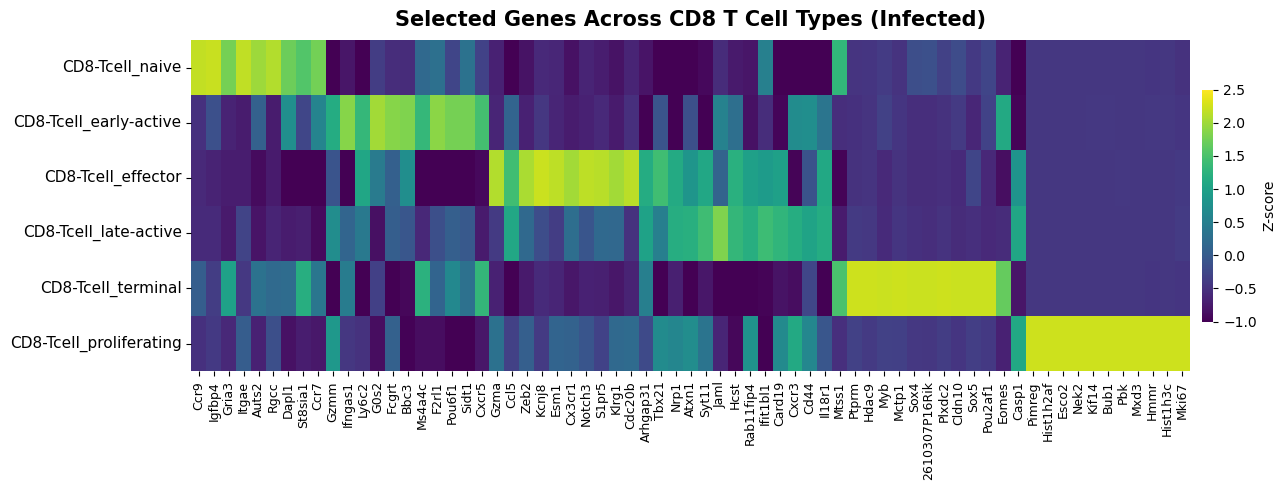


✅ CD8 Heatmap (infected only, no brackets) complete!


In [ ]:
print("Creating CD8 T cell heatmap with selected genes + favorite markers (INFECTED ONLY)...\n")

# Define cell type order
cd8_cell_type_order = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active',
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
    'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating'
]

# Manual gene assignments per cell type (from your DE analysis)
manual_genes_by_celltype = {
    'CD8-Tcell_naive': ['Ccr9', 'Igfbp4', 'Gria3', 'Itgae', 'Auts2', 'Rgcc', 'Dapl1', 'St8sia1', 'Ccr7', 'Mtss1'],
    'CD8-Tcell_early-active': ['Gzmm', 'Ifngas1', 'Ly6c2', 'G0s2', 'Fcgrt', 'Bbc3', 'Ms4a4c', 'F2rl1', 'Pou6f1', 'Sidt1'],
    'CD8-Tcell_effector': ['Gzma', 'Ccl5', 'Zeb2', 'Kcnj8', 'Esm1', 'Cx3cr1', 'Notch3', 'S1pr5', 'Klrg1', 'Cdc20b'],
    'CD8-Tcell_late-active': ['Nrp1', 'Casp1', 'Atxn1', 'Syt11', 'Jaml', 'Hcst', 'Rab11fip4', 'Ifit1bl1', 'Arhgap31', 'Card19'],
    'CD8-Tcell_terminal': ['Ptprm', 'Hdac9', 'Myb', 'Mctp1', 'Sox4', '2610307P16Rik', 'Plxdc2', 'Cldn10', 'Sox5', 'Pou2af1'],
    'CD8-Tcell_proliferating': ['Pimreg', 'Hist1h2af', 'Esco2', 'Nek2', 'Kif14', 'Bub1', 'Pbk', 'Mxd3', 'Hmmr', 'Hist1h3c']
}

# Favorite CD8 markers to add
favorite_markers = ['Cxcr3', 'Klrg1', 'Cd44', 'Eomes', 'Tbx21', 'Mki67', 'Il18r1', 'Cxcr5']

# Combine all genes
all_selected_genes = []
for ct in cd8_cell_type_order:
    all_selected_genes.extend(manual_genes_by_celltype[ct])

# Add favorite markers
all_selected_genes.extend(favorite_markers)

# Remove duplicates (Klrg1 is already in effector list)
all_selected_genes_unique = list(dict.fromkeys(all_selected_genes))

print(f"Total genes to plot: {len(all_selected_genes_unique)}")

# FILTER FOR INFECTED CELLS ONLY (3wk timepoint)
print("\nFiltering for infected cells (3wk timepoint)...")
adata_infected_only = adata_sc_new[adata_sc_new.obs['timepoint'] == '3wk'].copy()
print(f"Total infected cells: {adata_infected_only.shape[0]}")

# Filter for CD8 cells (6 main types only) - INFECTED
adata_cd8_infected = adata_infected_only[adata_infected_only.obs['celltypes_redo'].isin(cd8_cell_type_order)].copy()
print(f"Infected CD8 cells: {adata_cd8_infected.shape[0]}")

print("\nCells per population (infected only):")
for ct in cd8_cell_type_order:
    n_cells = (adata_cd8_infected.obs['celltypes_redo'] == ct).sum()
    print(f"  {ct}: {n_cells}")

# Check which genes are present in the data
cd8_genes_present = [g for g in all_selected_genes_unique if g in adata_cd8_infected.var_names]
cd8_genes_missing = [g for g in all_selected_genes_unique if g not in adata_cd8_infected.var_names]

print(f"\nGenes present: {len(cd8_genes_present)}/{len(all_selected_genes_unique)}")
if cd8_genes_missing:
    print(f"Missing genes ({len(cd8_genes_missing)}): {cd8_genes_missing}")

# Subset to genes
adata_cd8_subset = adata_cd8_infected[:, cd8_genes_present].copy()

# Calculate mean expression per cell type
print("\nCalculating mean expression...")
expr_matrix_cd8 = []
cell_type_labels_cd8 = []

for cell_type in cd8_cell_type_order:
    cells_mask = adata_cd8_subset.obs['celltypes_redo'] == cell_type
    cells = adata_cd8_subset[cells_mask]
    
    if cells.shape[0] > 0:
        if hasattr(cells.X, 'toarray'):
            X = cells.X.toarray()
        else:
            X = cells.X
        
        mean_expr = X.mean(axis=0)
        expr_matrix_cd8.append(mean_expr)
        cell_type_labels_cd8.append(cell_type)

# Create dataframe
expr_df_cd8_selected = pd.DataFrame(
    expr_matrix_cd8,
    index=cell_type_labels_cd8,
    columns=cd8_genes_present
)

# Z-score normalize
from scipy.stats import zscore
expr_df_cd8_selected_norm = expr_df_cd8_selected.apply(zscore, axis=0)
expr_df_cd8_selected_norm = expr_df_cd8_selected_norm.fillna(0)

# For each gene, find which cell type has highest expression
gene_to_peak_celltype = {}
for gene in expr_df_cd8_selected_norm.columns:
    peak_celltype = expr_df_cd8_selected_norm[gene].idxmax()
    gene_to_peak_celltype[gene] = peak_celltype

# Group genes by their peak cell type
genes_by_celltype_actual = {ct: [] for ct in cd8_cell_type_order}
for gene, peak_ct in gene_to_peak_celltype.items():
    genes_by_celltype_actual[peak_ct].append(gene)

# Order genes by cell type progression
ordered_genes_selected = []
for ct in cd8_cell_type_order:
    ordered_genes_selected.extend(genes_by_celltype_actual[ct])
    print(f"{ct}: {len(genes_by_celltype_actual[ct])} genes")

# Reorder columns by peak expression
expr_df_cd8_selected_ordered = expr_df_cd8_selected_norm[ordered_genes_selected]

# Create figure (NO BRACKETS)
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    expr_df_cd8_selected_ordered,
    cmap='RdBu_r',
    vmin=-1,
    vmax=2.5,
    cbar_kws={
        'label': 'Z-score',
        'shrink': 0.7,
        'pad': 0.01
    },
    linewidths=0.001,
    linecolor='white',
    square=False,
    ax=ax,
    yticklabels=True,
    xticklabels=True
)

ax.set_title('Selected Genes Across CD8 T Cell Types (Infected)', 
             fontsize=15, fontweight='bold', pad=10)

plt.xticks(rotation=90, ha='center', fontsize=9)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.savefig('cd8_selected_genes_heatmap_infected_only.png', dpi=300, bbox_inches='tight')
plt.savefig('cd8_selected_genes_heatmap_infected_only.pdf', bbox_inches='tight')
print("\n📊 Saved: cd8_selected_genes_heatmap_infected_only.png/pdf")
plt.show()

print(f"\n✅ CD8 Heatmap (infected only, no brackets) complete!")

In [ ]:
print("=" * 80)
print("VERIFICATION: TOP 10 GENES BY FOLD CHANGE vs TOP 10 BY EXPRESSION")
print("For each CD8 population vs ALL OTHER CD8 POPULATIONS (infected only)")
print("=" * 80)

# Use the 6 main CD8 populations
cd8_populations_main = [
    'CD8-Tcell_naive',
    'CD8-Tcell_early-active',
    'CD8-Tcell_effector',
    'CD8-Tcell_late-active',
    'CD8-Tcell_terminal',
    'CD8-Tcell_proliferating'
]

# Filter for significant genes (padj < 0.05 and positive logFC)
de_significant_cd8_check = de_infected_all[
    (de_infected_all['pvals_adj'] < 0.05) & 
    (de_infected_all['logfoldchanges'] > 0)
].copy()

# EXCLUDE Gm* genes
de_significant_cd8_check = de_significant_cd8_check[~de_significant_cd8_check['names'].str.startswith('Gm')].copy()
de_significant_cd8_check = de_significant_cd8_check[~de_significant_cd8_check['names'].str.startswith('Rps')].copy()
de_significant_cd8_check = de_significant_cd8_check[~de_significant_cd8_check['names'].str.startswith('Rp')].copy()
de_significant_cd8_check = de_significant_cd8_check[~de_significant_cd8_check['names'].str.startswith('mt-')].copy()
print(f"\nSignificant DE genes (padj < 0.05, logFC > 0, no Gm*): {len(de_significant_cd8_check)}\n")

# Calculate mean expression for each gene in each CD8 population
print("Calculating mean expression across CD8 populations...")
all_de_genes_cd8_check = de_significant_cd8_check['names'].unique()

# Use adata_cd8_all from the CD8 vs CD8 analysis (infected CD8s only)
mean_expr_cd8_check = {}

for pop in cd8_populations_main:
    pop_cells = adata_cd8_all[adata_cd8_all.obs['celltypes_redo'] == pop]
    
    if pop_cells.shape[0] > 0:
        genes_present = [g for g in all_de_genes_cd8_check if g in pop_cells.var_names]
        
        if len(genes_present) > 0:
            pop_subset = pop_cells[:, genes_present].copy()
            
            if hasattr(pop_subset.X, 'toarray'):
                X = pop_subset.X.toarray()
            else:
                X = pop_subset.X
            
            mean_expr = X.mean(axis=0)
            gene_expr_dict = dict(zip(genes_present, mean_expr))
            mean_expr_cd8_check[pop] = gene_expr_dict

print("✅ Expression calculated\n")

# For each population, get top 10 by fold change AND top 10 by expression
EXPRESSION_THRESHOLD = 0.1

for pop in cd8_populations_main:
    print("=" * 80)
    print(f"{pop}")
    print("=" * 80)
    
    # Get DE genes for this population (vs other CD8s)
    pop_de = de_significant_cd8_check[de_significant_cd8_check['population'] == pop].copy()
    
    # Add expression for this population
    if pop in mean_expr_cd8_check:
        pop_de['mean_expr'] = pop_de['names'].map(mean_expr_cd8_check[pop])
        
        # Filter by expression threshold
        pop_de_filtered = pop_de[pop_de['mean_expr'] >= EXPRESSION_THRESHOLD].copy()
        
        print(f"\nDE genes passing expression threshold (>= {EXPRESSION_THRESHOLD}): {len(pop_de_filtered)}\n")
        
        # TOP 10 BY FOLD CHANGE
        top10_fc = pop_de_filtered.nlargest(10, 'logfoldchanges')[['names', 'logfoldchanges', 'mean_expr', 'pvals_adj']]
        
        print("TOP 10 BY FOLD CHANGE (vs other CD8s):")
        print("-" * 70)
        for idx, (_, row) in enumerate(top10_fc.iterrows(), 1):
            print(f"  {idx:2d}. {row['names']:20s}  logFC={row['logfoldchanges']:6.2f}  expr={row['mean_expr']:.3f}  padj={row['pvals_adj']:.2e}")
        
        # TOP 10 BY EXPRESSION
        top10_expr = pop_de_filtered.nlargest(10, 'mean_expr')[['names', 'mean_expr', 'logfoldchanges', 'pvals_adj']]
        
        print("\nTOP 10 BY EXPRESSION (in this population):")
        print("-" * 70)
        for idx, (_, row) in enumerate(top10_expr.iterrows(), 1):
            print(f"  {idx:2d}. {row['names']:20s}  expr={row['mean_expr']:.3f}  logFC={row['logfoldchanges']:6.2f}  padj={row['pvals_adj']:.2e}")
        
        # OVERLAP - genes in both lists
        genes_fc = set(top10_fc['names'].tolist())
        genes_expr = set(top10_expr['names'].tolist())
        overlap = genes_fc.intersection(genes_expr)
        
        print(f"\nOVERLAP (genes in both top 10 lists): {len(overlap)}")
        if overlap:
            print(f"  {', '.join(sorted(overlap))}")
        
        print()

print("=" * 80)
print("✅ Verification complete!")
print("=" * 80)

VERIFICATION: TOP 10 GENES BY FOLD CHANGE vs TOP 10 BY EXPRESSION
For each CD8 population vs ALL OTHER CD8 POPULATIONS (infected only)

Significant DE genes (padj < 0.05, logFC > 0, no Gm*): 11092

Calculating mean expression across CD8 populations...
✅ Expression calculated

CD8-Tcell_naive

DE genes passing expression threshold (>= 0.1): 934

TOP 10 BY FOLD CHANGE (vs other CD8s):
----------------------------------------------------------------------
   1. Ccr9                  logFC=  3.73  expr=0.428  padj=0.00e+00
   2. Igfbp4                logFC=  3.40  expr=0.290  padj=2.99e-274
   3. Gria3                 logFC=  3.38  expr=0.114  padj=5.29e-101
   4. Itgae                 logFC=  2.88  expr=0.202  padj=5.22e-171
   5. Auts2                 logFC=  2.61  expr=0.260  padj=7.04e-150
   6. Rgcc                  logFC=  2.48  expr=0.396  padj=2.58e-304
   7. Dapl1                 logFC=  2.38  expr=0.707  padj=0.00e+00
   8. St8sia1               logFC=  2.38  expr=0.285  padj=7.9

In [ ]:
print("=" * 80)
print("INVESTIGATING SPECIFIC GENES - CD8 NAIVE POPULATION")
print("Checking Itgae and other expected naive markers")
print("=" * 80)

# Genes to check for naive cells
genes_to_check = ['Itgae', 'Ccr7', 'Ccr9', 'Sell', 'Lef1', 'Tcf7', 'Cd62l', 'Il7r', 'Cd8b1']

pop = 'CD8-Tcell_naive'

print(f"\nPopulation: {pop}")
print("=" * 60)

# Get DE results for naive (vs other CD8s)
pop_de_all = de_infected_all[de_infected_all['population'] == pop].copy()

# Add expression values
if pop in mean_expr_cd8_check:
    pop_de_all['mean_expr'] = pop_de_all['names'].map(mean_expr_cd8_check[pop])

print(f"\nTotal DE genes for {pop}: {len(pop_de_all)}")
print(f"Significant (padj < 0.05): {len(pop_de_all[pop_de_all['pvals_adj'] < 0.05])}")

print("\nChecking specific genes:")
print("-" * 80)

for gene in genes_to_check:
    gene_data = pop_de_all[pop_de_all['names'] == gene]
    
    if len(gene_data) > 0:
        row = gene_data.iloc[0]
        
        # Calculate rank by logFC and by expression
        sig_genes = pop_de_all[
            (pop_de_all['pvals_adj'] < 0.05) & 
            (pop_de_all['logfoldchanges'] > 0) &
            (~pop_de_all['names'].str.startswith('Gm'))
        ].copy()
        
        if len(sig_genes) > 0 and row['pvals_adj'] < 0.05:
            rank_fc = (sig_genes['logfoldchanges'] > row['logfoldchanges']).sum() + 1
            
            if 'mean_expr' in sig_genes.columns:
                sig_genes_with_expr = sig_genes[sig_genes['mean_expr'] >= EXPRESSION_THRESHOLD]
                rank_expr = (sig_genes_with_expr['mean_expr'] > row['mean_expr']).sum() + 1
            else:
                rank_expr = "N/A"
        else:
            rank_fc = "Not sig"
            rank_expr = "Not sig"
        
        print(f"{gene:12s}  logFC={row['logfoldchanges']:6.2f} (rank: {rank_fc})  "
              f"expr={row['mean_expr']:.3f} (rank: {rank_expr})  padj={row['pvals_adj']:.2e}")
    else:
        print(f"{gene:12s}  NOT FOUND in DE results")

# Also check expression in ALL CD8 populations for context
print("\n" + "=" * 80)
print("EXPRESSION OF ITGAE ACROSS ALL CD8 POPULATIONS")
print("=" * 80)

if 'Itgae' in adata_cd8_all.var_names:
    for pop_check in cd8_populations_main:
        if pop_check in mean_expr_cd8_check and 'Itgae' in mean_expr_cd8_check[pop_check]:
            expr = mean_expr_cd8_check[pop_check]['Itgae']
            print(f"{pop_check:30s}  expr={expr:.3f}")
    
    # Find which population has highest Itgae expression
    itgae_expr_all = {p: mean_expr_cd8_check[p].get('Itgae', 0) 
                      for p in cd8_populations_main if p in mean_expr_cd8_check}
    max_pop = max(itgae_expr_all, key=itgae_expr_all.get)
    print(f"\nHighest Itgae expression: {max_pop} (expr={itgae_expr_all[max_pop]:.3f})")
else:
    print("Itgae not found in dataset")

print("\n✅ Investigation complete!")

INVESTIGATING SPECIFIC GENES - CD8 NAIVE POPULATION
Checking Itgae and other expected naive markers

Population: CD8-Tcell_naive

Total DE genes for CD8-Tcell_naive: 32984
Significant (padj < 0.05): 7673

Checking specific genes:
--------------------------------------------------------------------------------
Itgae         logFC=  2.88 (rank: 31)  expr=0.202 (rank: 547)  padj=5.22e-171
Ccr7          logFC=  2.37 (rank: 48)  expr=0.563 (rank: 152)  padj=0.00e+00
Ccr9          logFC=  3.73 (rank: 12)  expr=0.428 (rank: 217)  padj=0.00e+00
Sell          logFC=  1.30 (rank: 225)  expr=0.990 (rank: 57)  padj=2.05e-287
Lef1          logFC=  1.75 (rank: 118)  expr=1.643 (rank: 14)  padj=0.00e+00
Tcf7          logFC=  0.91 (rank: 443)  expr=1.028 (rank: 48)  padj=1.31e-171
Cd62l         NOT FOUND in DE results
Il7r          logFC=  0.60 (rank: 833)  expr=1.095 (rank: 41)  padj=3.79e-53
Cd8b1         logFC=  1.34 (rank: 215)  expr=1.560 (rank: 15)  padj=3.51e-307

EXPRESSION OF ITGAE ACROSS ALL